# Library dan Konfigurasi

## Import Library

In [1]:
import ast
import io
import json
import os
import re
import shutil
import subprocess
import sys
import stat
import time
import tokenize
from collections import defaultdict
from datetime import datetime
import pickle
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import normalize


# Formatter untuk standarisasi kode Python
import autopep8
import black

# Engine export Excel untuk pandas
import openpyxl

# Progress bar & notebook display
from tqdm.notebook import tqdm
from IPython.display import display, HTML

# Waktu
run_time = datetime.now()

# Konfigurasi visualisasi default
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

print("=" * 65)
print(f"{'LIBRARY INITIALIZATION':^65}")
print("-" * 65)
print(f"Python     : {sys.version.split()[0]}")
print(f"✅ {run_time.strftime('%Y-%m-%d %H:%M:%S')} - Libraries loaded successfully.")
print("-" * 65)

                     LIBRARY INITIALIZATION                      
-----------------------------------------------------------------
Python     : 3.10.6
✅ 2026-06-10 02:02:21 - Libraries loaded successfully.
-----------------------------------------------------------------


## Konfigurasi

In [2]:
# ==============================================================================
# DIRECTORY CONFIGURATION & INITIALIZATION
# Menentukan path utama, struktur folder dataset, dan file output
# ==============================================================================

# Root directory dan file input
BASE_DIR = r"D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code"
DATASET_FOLDER = "dataset(2)"
OUTPUT_FOLDER = "output(2)"

INPUT_GITHUB = os.path.join(BASE_DIR, "asli", "nim_github.txt")

# Struktur folder pipeline
DIRS = {
    "DATASET"      : os.path.join(BASE_DIR, DATASET_FOLDER),

    # Preprocessing
    "RAW"          : os.path.join(BASE_DIR, DATASET_FOLDER, "00_Raw"),
    "ANON"          : os.path.join(BASE_DIR, DATASET_FOLDER, "01_Raw_Anon"),
    "CONV"         : os.path.join(BASE_DIR, DATASET_FOLDER, "03_Converted"),
    "CLEAN"        : os.path.join(BASE_DIR, DATASET_FOLDER, "04_Cleaned"),

    # Formatter experiment
    "AUTOPEP8"     : os.path.join(BASE_DIR, DATASET_FOLDER, "05a_Autopep8"),
    "BLACK"        : os.path.join(BASE_DIR, DATASET_FOLDER, "05b_Black"),
    
    "FILTERED"     : os.path.join(BASE_DIR, DATASET_FOLDER, "06_Filtered"),

    # AST & Graph
    "AST"          : os.path.join(BASE_DIR, DATASET_FOLDER, "07_AST"),
    "AST_VISUAL"   : os.path.join(BASE_DIR, DATASET_FOLDER, "07a_AST_visual"),
    "GRAPH"        : os.path.join(BASE_DIR, DATASET_FOLDER, "08_Graph"),
    "INPUT_GRAPH"  : os.path.join(BASE_DIR, DATASET_FOLDER, "09_Graph2vec_Input"),
    "EMBEDDING"    : os.path.join(BASE_DIR, DATASET_FOLDER, "10_Graph2vec_Embedding"),

    # Output
    "LOGS"         : os.path.join(BASE_DIR, OUTPUT_FOLDER),
    "RUNTIME_A"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_autopep8"),
    "RUNTIME_B"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_black"),
    
    # folder output untuk grafik similarity
    "SIMILARITY"   : os.path.join(BASE_DIR, OUTPUT_FOLDER,"similarity"),
}

# File output penelitian
RESULTS = {
    # Preprocessing
    "CLONE_REPORT"    : os.path.join(DIRS["LOGS"], "01_clone_report.xlsx"),
    "NORM_REPORT"     : os.path.join(DIRS["LOGS"], "02_normalization_report.xlsx"),
    "CONV_REPORT"     : os.path.join(DIRS["LOGS"], "03_conversion_report.xlsx"),
    "CLEAN_REPORT"    : os.path.join(DIRS["LOGS"], "04_cleaning_report.xlsx"),

    # Formatter
    "ERR_AUTOPEP"     : os.path.join(DIRS["LOGS"], "05a_autopep_errors.json"),
    "ERR_BLACK"       : os.path.join(DIRS["LOGS"], "05b_black_errors.json"),

    # Runtime Autopep8
    "RUN_PROJECT_A"   : os.path.join(DIRS["RUNTIME_A"], "a_runtime_project_AUTOPEP8.xlsx"),
    "RUN_FUNCTION_A"  : os.path.join(DIRS["RUNTIME_A"], "b_runtime_function_AUTOPEP8.xlsx"),
    "RUN_COMPARE_A"   : os.path.join(DIRS["RUNTIME_A"], "c_runtime_compare_AUTOPEP8.xlsx"),

    # Runtime Black
    "RUN_PROJECT_B"   : os.path.join(DIRS["RUNTIME_B"], "a_runtime_project_BLACK.xlsx"),
    "RUN_FUNCTION_B"  : os.path.join(DIRS["RUNTIME_B"], "b_runtime_function_BLACK.xlsx"),
    "RUN_COMPARE_B"   : os.path.join(DIRS["RUNTIME_B"], "c_runtime_compare_BLACK.xlsx"),

    # Submission
    "SUBMISSION"      : os.path.join(DIRS["LOGS"], "06_submission_report.xlsx"),

    # AST & Graph
    "EXTRACT_AST"     : os.path.join(DIRS["LOGS"], "07_AST_report.xlsx"),
    "CONSTRUCT_GRAPH" : os.path.join(DIRS["LOGS"], "08_Graph_report.xlsx"),
    "LIST_GRAPH"      : os.path.join(DIRS["LOGS"], "09_list_Graph_report.xlsx"),

    # Graph2Vec
    "EMBEDDING_REPORT": os.path.join(DIRS["LOGS"], "10_embedding_report.xlsx"),
    "EMBEDDING_VECTOR": os.path.join(DIRS["LOGS"], "10a_embedding_vector.xlsx"),

    # Similarity
    "SIMILARITY"      : os.path.join(DIRS["LOGS"], "11_similarity_report.xlsx"),
    "SIMILARITY_MODUL" : os.path.join(DIRS['LOGS'], "11a_similarity_per_Modul.xlsx"),
    "SIMILARITY_SUMMARY" : os.path.join(DIRS['LOGS'], "11b_similarity_summary.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN" : os.path.join(DIRS['LOGS'], "12_euclidean_similarity.xlsx"),
    "EUCLIDEAN_MODUL" : os.path.join(DIRS['LOGS'], "12a_euclidean_similarity_modul.xlsx"),
    
    "SIMILARITY_COMPARE" : os.path.join(DIRS['LOGS'], "13_similarity_comparison.xlsx"),
    
    # METRICS
    "METRICS"         : os.path.join(DIRS["LOGS"], "metrics_evaluation_report.xlsx"),
}

# VALIDATION & DIRECTORY INITIALIZATION
print("=" * 70)
print(f"{'DIRECTORY CONFIGURATION':^70}")
print("=" * 70)

# Validasi root directory
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(f"❌ BASE_DIR tidak ditemukan: {BASE_DIR}")

# Validasi file input
if not os.path.isfile(INPUT_GITHUB):
    raise FileNotFoundError(f"❌ File input tidak ditemukan: {INPUT_GITHUB}")

if not INPUT_GITHUB.endswith(".txt"):
    raise ValueError("❌ File input harus berekstensi .txt")

if os.path.getsize(INPUT_GITHUB) == 0:
    raise ValueError(f"❌ File input kosong: {INPUT_GITHUB}")

# Membuat folder pipeline
folders_created = 0

for name, path in DIRS.items():
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        folders_created += 1
        status = "[NEW]"
    elif not os.path.isdir(path):
        raise NotADirectoryError(f"❌ Path bukan folder: {path}")
    else:
        status = "[EXISTS]"
    print(f"{status:<10} {name:<12} : {path}")

# Validasi parent folder output
missing_results_parent = []

for name, path in RESULTS.items():
    parent_dir = os.path.dirname(path)
    if not os.path.exists(parent_dir):
        missing_results_parent.append(
            f"{name} : {parent_dir}"
        )

if missing_results_parent:
    raise FileNotFoundError(
        "❌ Parent folder RESULTS tidak ditemukan:\n"
        + "\n".join(missing_results_parent)
    )

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("-" * 70)
print(f"Folders Created  : {folders_created}")
print(f"Dataset Root     : {DIRS['DATASET']}")
print(f"Input File       : {INPUT_GITHUB}")
print("=" * 70)
print(f"Diproses pada {timestamp}")

                       DIRECTORY CONFIGURATION                        
[EXISTS]   DATASET      : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)
[EXISTS]   RAW          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\00_Raw
[EXISTS]   ANON         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\01_Raw_Anon
[EXISTS]   CONV         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\03_Converted
[EXISTS]   CLEAN        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\04_Cleaned
[EXISTS]   AUTOPEP8     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05a_Autopep8
[EXISTS]   BLACK        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05b_Black
[EXISTS]   FILTERED     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\06_Filtered
[EXISTS]   AST          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\07_AST
[EXISTS]   AST_VISUAL   : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\07a_AST_visual
[EXISTS]   GRAPH        : D:\PUTRI\D4\SEMESTER 8 

## Helper Function

In [3]:
# HELPER FUNCTION Hitung File dalam dataset

def count_all_files(dataset_path, extensions=None, exclude_dirs=None):
    total_files = 0
    by_extension = {}

    exclude_dirs = set(exclude_dirs or [])

    for root, dirs, files in os.walk(dataset_path):
        # skip folder tertentu
        dirs[:] = [d for d in dirs if d not in exclude_dirs]

        for file in files:
            ext = os.path.splitext(file)[1].lower()

            # filter ekstensi jika diberikan
            if extensions and ext not in extensions:
                continue

            total_files += 1
            by_extension[ext] = by_extension.get(ext, 0) + 1

    return {
        "total_files": total_files,
        "by_extension": by_extension
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-10 02:02:21


In [4]:
# ==============================================================================
# METRIC EVALUATION HELPERS
# ==============================================================================
def save_stage_evaluation(report_path, stage_name, total_files, total_size_kb, execution_time, total_loc=0):
    """Simpan atau perbarui evaluasi makro per tahap ke sheet 'stage_level_evaluation'."""
    SHEET = "stage_level_evaluation"
    avg_size = (total_size_kb / total_files if total_files > 0 else 0)
    avg_loc = (total_loc / total_files if total_files > 0 else 0)
    
    new_row = {
        "Tahap": stage_name, "Total File": total_files, "Total Size (KB)": round(total_size_kb, 2),
        "Avg Size per File (KB)": round(avg_size, 2), "Avg LOC per File": round(avg_loc, 2),
        "Waktu Eksekusi (s)": round(execution_time, 2)
    }

    # Gunakan dictionary untuk membaca seluruh sheet yang ada agar aman dari korup data
    all_sheets = {}
    if os.path.exists(report_path):
        try:
            with pd.ExcelFile(report_path, engine="openpyxl") as xls:
                for sheet in xls.sheet_names:
                    all_sheets[sheet] = pd.read_excel(xls, sheet_name=sheet)
        except Exception:
            pass

    # Ambil data lama khusus untuk sheet ini atau buat baru
    df = all_sheets.get(SHEET, pd.DataFrame())

    if not df.empty and "Tahap" in df.columns and stage_name in df["Tahap"].values:
        mask = df["Tahap"] == stage_name
        df.loc[mask, ["Total File", "Total Size (KB)", "Avg Size per File (KB)", "Avg LOC per File", "Waktu Eksekusi (s)"]] = [
            total_files, round(total_size_kb, 2), round(avg_size, 2), round(avg_loc, 2), round(execution_time, 2)
        ]
    else:
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    
    all_sheets[SHEET] = df

    # Tulis ulang seluruh sheet secara aman (Menghindari bug mode='a' openpyxl)
    with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
        for sheet, df_sheet in all_sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet, index=False)


def save_bulk_detail_metrics(report_path, sheet_name, metrics_list, stage_name):
    """
    Menyimpan metrik mikro secara massal (Bulk) untuk menghemat I/O Disk.
    metrics_list berisi list of dict: [{'nim':..., 'modul':..., 'file':..., 'value':...}]
    """
    if not metrics_list:
        return

    identity_cols = ["nim", "modul", "file_id"]
    
    # Read semua sheet lama agar data di sheet lain tidak hilang
    all_sheets = {}
    if os.path.exists(report_path):
        try:
            with pd.ExcelFile(report_path, engine="openpyxl") as xls:
                for sheet in xls.sheet_names:
                    all_sheets[sheet] = pd.read_excel(xls, sheet_name=sheet)
        except Exception:
            pass

    df = all_sheets.get(sheet_name, pd.DataFrame(columns=identity_cols))
    
    df_batch = pd.DataFrame(metrics_list)
    df_batch = df_batch.rename(
        columns={"value": stage_name}
    )
    df_batch = df_batch[
        ["nim", "modul", "file_id", stage_name]
    ]
    
    if df.empty:
        df = df_batch.copy()
    else:
        df = df.merge(
            df_batch,
            on=identity_cols,
            how="outer"
        )
    # Pastikan tipe data kolom identitas konsisten menjadi string agar pencocokan mask akurat
    for col in identity_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    # Pastikan kolom stage_name sudah tersedia
    if stage_name not in df.columns:
        df[stage_name] = None
        
    df_batch = pd.DataFrame(metrics_list)
    # Bersihkan whitespace dan seragamkan tipe data batch baru ke string
    for col in identity_cols:
        df_batch[col] = df_batch[col].astype(str).str.strip()
    
    # Amankan batch jika di dalam list RAM itu sendiri ada record duplikat (ambil yang terakhir)
    df_batch = df_batch.drop_duplicates(subset=identity_cols, keep='last')

    # Lakukan sinkronisasi data dari memori RAM ke DataFrame
    for item in metrics_list:
        nim, modul, file_name, value, file_id = item['nim'], item['modul'], item['file'], item['value'], item['file_id']
        mask = (df["nim"] == nim) & (df["modul"] == modul) & (df["file_id"] == file_id)
        
        if mask.any():
            df.loc[mask, stage_name] = round(value, 4)
        else:
            new_row = {"nim": str(nim), "modul": modul, "file": file_name, "file_id": file_id, stage_name: round(value, 4)}
            new_df = pd.DataFrame([new_row])
            # Hindari FutureWarning pandas
            if df.empty:
                df = new_df.copy()
            else:
                for col in df.columns:
                    if col not in new_df.columns:
                        new_df[col] = None

                for col in new_df.columns:
                    if col not in df.columns:
                        df[col] = None

                df = pd.concat([df, new_df[df.columns]], ignore_index=True)

    all_sheets[sheet_name] = df

    # Flush massal ke berkas Excel tunggal
    with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
        for sheet, df_sheet in all_sheets.items():
            df_sheet.to_excel(writer, sheet_name=sheet, index=False)
            # Mengatur kelebaran kolom otomatis untuk semua sheet yang aktif
            worksheet = writer.sheets[sheet]
            for col in worksheet.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                worksheet.column_dimensions[col[0].column_letter].width = max(max_len + 3, 20)


def get_path_size(path, unit="kb"):
    """Menghitung kapasitas memori file/folder secara rekursif."""
    if not os.path.exists(path):
        return 0

    total_size = 0
    if os.path.isfile(path):
        try: total_size = os.path.getsize(path)
        except Exception: return 0
    else:
        for root, _, files in os.walk(path):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    if os.path.exists(file_path): total_size += os.path.getsize(file_path)
                except Exception: pass

    unit = unit.lower()
    factors = {"byte": 1, "kb": 1024, "mb": 1024**2, "gb": 1024**3}
    if unit in factors:
        return total_size if unit == "byte" else round(total_size / factors[unit], 4)
    else:
        raise ValueError("Unit tidak valid. Gunakan: byte/kb/mb/gb")


def count_loc(file_path):
    """Menghitung kuantitas baris kode aktif (tanpa baris kosong)."""
    if not os.path.exists(file_path):
        return 0

    ext = os.path.splitext(file_path)[1].lower()
    try:
        if ext == ".py":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                return sum(1 for line in f if line.strip())
        elif ext == ".ipynb":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                notebook = json.load(f)
            loc = 0
            for cell in notebook.get("cells", []):
                if cell.get("cell_type") == "code":
                    source = cell.get("source", [])
                    loc += sum(1 for line in source if str(line).strip())
            return loc
        return 0
    except Exception:
        return 0

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-10 02:02:21


In [5]:
# HELPER FUNCTION UNTUK TRACE CLONE FRAGMENT BERBASIS WL SUBGRAPH
import os
import networkx as nx
import pandas as pd
from hashlib import md5

def get_wl_subgraph_features_with_lines(G, radius=2):
    """
    Merekonstruksi algoritma Weisfeiler-Lehman Subgraph Extraction.
    Mengembalikan dictionary berisi token fitur subgraph beserta daftar lineno penyusunnya.
    """
    # Inisialisasi label dasar (iterasi radius 0)
    current_labels = {node: str(data.get('feature', '')) for node, data in G.nodes(data=True)}
    
    # Simpan jejak lineno dasar untuk setiap node
    node_lines = {}
    for node, data in G.nodes(data=True):
        lineno = data.get("lineno")
        end_lineno = data.get("end_lineno")
        if lineno:
            if end_lineno and end_lineno >= lineno:
                node_lines[node] = list(
                    range(lineno, end_lineno + 1)
                )
            else:
                node_lines[node] = [lineno]
    
    # Tempat menyimpan fitur subgraph final beserta lineno akumulasinya
    wl_features = {}
    
    # Jalankan iterasi perluasan radius lingkungan graf (Weisfeiler-Lehman step)
    for r in range(radius + 1):
        next_labels = {}
        for node in G.nodes():
            # 1. Kumpulkan label dari tetangga terdekat
            neighbors = sorted([current_labels[nbr] for nbr in G.neighbors(node)])
            # 2. Gabungkan label node pusat dengan tetangga
            joined_label = current_labels[node] + "-" + "".join(neighbors)
            # 3. Lakukan kompresi label menggunakan hashing MD5 (Standar industri Graph2Vec)
            compressed_hash = md5(joined_label.encode('utf-8')).hexdigest()
            next_labels[node] = compressed_hash
            
            # 4. Akumulasikan seluruh nomor baris dari node bersangkutan dan tetangganya
            subgraph_lines = list(node_lines.get(node, []))
            for nbr in G.neighbors(node):
                if nbr in node_lines:
                    subgraph_lines.extend(node_lines[nbr])
            
            # Bersihkan dari duplikasi nomor baris
            subgraph_lines = sorted(list(set(subgraph_lines)))
            
            # Daftarkan token sub-graph unik ini ke dalam dictionary database
            if compressed_hash not in wl_features:
                wl_features[compressed_hash] = []
            wl_features[compressed_hash].extend(subgraph_lines)
            
        current_labels = next_labels
        
    # Saring hasil akhir agar lineno di setiap token unik terlindungi
    for hash_token in wl_features:
        wl_features[hash_token] = sorted(list(set(wl_features[hash_token])))
        
    return wl_features

def build_line_ranges(lines):
    if not lines:
        return []
    lines = sorted(set(lines))
    ranges = []
    start = lines[0]
    prev = lines[0]

    for line in lines[1:]:
        if line == prev + 1:
            prev = line
            continue
        ranges.append((start, prev))
        start = line
        prev = line

    ranges.append((start, prev))
    return ranges

def extract_fragment(file_path, start_line, end_line):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    return "".join(lines[start_line - 1:end_line]).strip()

def trace_clone_fragment_by_wl(G_A, G_B, file_path_A, file_path_B,wl_cache=None, graph_key_A=None, graph_key_B=None, radius=2):
    """
    Membandingkan token WL Subgraph mhs A & B untuk mengisolasi koordinat lineno
    penyebab kemiripan, lalu mengambil teks fragmen aslinya.
    """
    if G_A is None or G_B is None:
        return "-", "-"
        
    # 1. Ekstrak peta WL Subgraph + Lineno dari masing-masing Graf AST
    if wl_cache is None:
        wl_cache = {}
    # Graph A
    if graph_key_A in wl_cache:
        wl_A = wl_cache[graph_key_A]
    else:
        wl_A = get_wl_subgraph_features_with_lines(G_A, radius=radius)
        wl_cache[graph_key_A] = wl_A
    # Graph B
    if graph_key_B in wl_cache:
        wl_B = wl_cache[graph_key_B]
    else:
        wl_B = get_wl_subgraph_features_with_lines(G_B, radius=radius)
        wl_cache[graph_key_B] = wl_B
    
    # 2. Cari persinggungan token (subgraph mana saja yang sama persis di kedua graf)
    common_subgraphs = set(wl_A.keys()).intersection(set(wl_B.keys()))
    
    lines_A = []
    lines_B = []
    
    # Kumpulkan seluruh lineno yang mendasari terbentuknya subgraph kembar tersebut
    for token in common_subgraphs:
        lines_A.extend(wl_A[token])
        lines_B.extend(wl_B[token])
    if not lines_A or not lines_B:
        return "Tidak ditemukan kesamaan subgraph struktural", "Tidak ditemukan kesamaan subgraph struktural"
        
    # 3. Ambil koordinat rentang baris terkecil dan terbesar
    ranges_A = build_line_ranges(lines_A)
    ranges_B = build_line_ranges(lines_B)
    largest_A = max(
        ranges_A,
        key=lambda x: x[1] - x[0]
    )
    largest_B = max(
        ranges_B,
        key=lambda x: x[1] - x[0]
    )
    start_A, end_A = largest_A
    start_B, end_B = largest_B
    
    # 4. Fungsi internal pembaca teks file fisik sumber di DIRS['FILTERED']
    def cut_text(path, start, end):
        if not os.path.exists(path): return "-"
        try:
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                all_file_lines = f.readlines()
            fragment = "".join(all_file_lines[start - 1 : end]).strip()
            return f"[Baris {start}-{end}]\n{fragment}"
        except Exception as e:
            return f"Gagal baca berkas: {str(e)}"
            
    fragment_A = cut_text(file_path_A, start_A, end_A)
    fragment_B = cut_text(file_path_B, start_B, end_B)
    
    return {
        "lineA": f"L{start_A}-L{end_A}",
        "lineB": f"L{start_B}-L{end_B}",
        "fragment_A": fragment_A,
        "fragment_B": fragment_B
    }

def save_similarity_with_subgraph_fragments(report_path, filtered_dataset_dir, match_results, graph_database):
    """
    Menyimpan laporan similarity, melacak fragment plagiat berdasarkan kesamaan 
    Weisfeiler-Lehman Subgraph, mengamankan format NIM, dan merapikan kolom Excel.
    """
    if not match_results:
        print("⚠️ Antrean data kosong.")
        return

    processed_records = []
    wl_cache = {}
    for item in tqdm(match_results, desc="Extracting Clone Fragments", unit="pair"):
        modul = str(item['modul']).strip()
        file_base = str(item['file']).strip()
        nim_1 = str(item['nim_1']).strip()
        nim_2 = str(item['nim_2']).strip()
        score = float(item['similarity_score'])
        kategori = str(item['kategori']).strip()

        lineA = "-"
        lineB = "-"
        fragment_code_A = "-"
        fragment_code_B = "-"

        # Ambil fragmen hanya jika file dicurigai klon (Bukan kategori 'Aman')
        if score != 0.0:
            # Tarik objek networkx Graph asli milik mhs A dan B dari dictionary database RAM Anda
            graph_A_data = graph_database.get(
                f"{nim_1}_{modul}_{file_base}"
            )
            graph_B_data = graph_database.get(
                f"{nim_2}_{modul}_{file_base}"
            )
            graph_key_A = f"{nim_1}_{modul}_{file_base}"
            graph_key_B = f"{nim_2}_{modul}_{file_base}"

            if graph_A_data and graph_B_data:
                G_A = graph_A_data["graph"]
                G_B = graph_B_data["graph"]
                full_path_A = graph_A_data["source_path"]
                full_path_B = graph_B_data["source_path"]

            else:
                G_A = None
                G_B = None
                full_path_A = None
                full_path_B = None

            # Ekstrak fragmen murni menggunakan penelusuran subgraph WL
            trace_result = trace_clone_fragment_by_wl(G_A, G_B, full_path_A, full_path_B, wl_cache=wl_cache, graph_key_A=graph_key_A, graph_key_B=graph_key_B)
            if isinstance(trace_result, dict):
                lineA = trace_result["lineA"]
                lineB = trace_result["lineB"]
                fragment_code_A = trace_result["fragment_A"]
                fragment_code_B = trace_result["fragment_B"]

        processed_records.append({
            "modul": modul,
            "file": file_base,
            "nim_1": nim_1,
            "nim_2": nim_2,
            "similarity_score": round(score,4),
            "kategori": kategori,
            "lineA": lineA,
            "lineB": lineB,
            "fragment_code_A": fragment_code_A,
            "fragment_code_B": fragment_code_B
        })

    # Buat DataFrame & Kunci NIM agar tidak menjadi Scientific Notation
    df_report = pd.DataFrame(processed_records)
    df_report["nim_1"] = df_report["nim_1"].astype(str)
    df_report["nim_2"] = df_report["nim_2"].astype(str)
    df_report = df_report.sort_values(by="similarity_score", ascending=False).reset_index(drop=True)
    print(f"WL Cache Size : {len(wl_cache):,}")
    os.makedirs(os.path.dirname(report_path) if os.path.dirname(report_path) else '.', exist_ok=True)
    return pd.DataFrame(processed_records)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-10 02:02:22


# Modeling (Graph2vec + Cosine Similarity)

## 10. Graph2vec

In [19]:
from karateclub import Graph2Vec
from sklearn.preprocessing import StandardScaler
# ==============================================================================
# FUNCTION HELPER - GRAPH2VEC MODELING
# ==============================================================================

def collect_group_files(input_dir):
    """Ambil semua file .pkl hasil grouping."""
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            if f.endswith(".pkl"):
                files.append(os.path.join(root, f))
    return files

def load_group_file(filepath):
    """Load graph + metadata per group."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        return data.get("graphs", []), data.get("metadata", []), "SUCCESS", ""
    except Exception as e:
        return [], [], "FAILED", str(e)

def train_graph2vec(graphs, dimensions=128, wl_iterations=2, epochs=100, learning_rate=0.025):
    """
    Melatih model Graph2Vec.
    Parameter penting:
    - attributed=True: Wajib agar model membaca atribut 'feature' yang sudah dibuat.
    - dimensions: Jumlah kolom vektor yang akan dihasilkan (default 128).
    - wl_iterations: Kedalaman penelusuran tetangga node (semakin besar, semakin luas konteksnya).
    """
    model = Graph2Vec(
        wl_iterations=wl_iterations,
        attributed=True,          
        dimensions=dimensions, 
        epochs=epochs,
        learning_rate=learning_rate
    )
    
    model.fit(graphs)
    return model.get_embedding()

def save_embeddings(embeddings, metadata, output_pkl):
    """Simpan embedding ke PKL & CSV."""
    os.makedirs(os.path.dirname(output_pkl), exist_ok=True)

    # PKL
    with open(output_pkl, "wb") as f:
        pickle.dump({"embeddings": embeddings, "metadata": metadata}, f)

    # CSV
    df_meta = pd.DataFrame(metadata)
    df_vec = pd.DataFrame(embeddings, columns=[f"v_{i}" for i in range(embeddings.shape[1])])
    df_final = pd.concat([df_meta, df_vec], axis=1)
    ast_cols = [
        "nodes",
        "edges",
        "kedalaman_ast",
        "jumlah_function",
        "jumlah_variabel_unik",
        "loc"
    ]
    # Sinkronisasi kolom: pastikan kolom metrik tersedia di dalam dataset final
    ast_cols = [c for c in ast_cols if c in df_final.columns]
    g2v_cols = [c for c in df_final.columns if c.startswith("g2v_")]
    feature_cols = ast_cols + g2v_cols

    if feature_cols:
        scaler = StandardScaler()
        # Transformasi nilai fitur agar memiliki mean = 0 dan standard deviation = 1
        df_final[feature_cols] = scaler.fit_transform(df_final[feature_cols])
    return df_final

def save_log(file, modul, filename, n_graph, status, message):
    return {
        "file_group": file,
        "modul": modul,
        "file": filename,
        "jumlah_graph": n_graph,
        "status": status,
        "keterangan": message
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Graph2Vec dijalankan pada {timestamp}")

✅ Helper functions untuk Graph2Vec dijalankan pada 2026-06-09 03:25:13


In [25]:
# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['INPUT_GRAPH']      # hasil grouping graph
OUTPUT_DIR = DIRS['EMBEDDING']       # folder embedding
REPORT_PATH = RESULTS['EMBEDDING_REPORT']

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)
# os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)

group_files = collect_group_files(INPUT_DIR)
graph_database = {}
all_embeddings = []
logs = []
success = 0
skipped = 0
failed = 0
embedding_start = time.time()
runtime_batch = []

print("="*70)
print(f"{' GRAPH2VEC EMBEDDING (PER FILE) ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Total File Graph Collection':<30}: {len(group_files)}")

for filepath in tqdm(group_files, desc="Graph2Vec Processing", unit="file"):
    filename = os.path.basename(filepath)
    modul = os.path.basename(os.path.dirname(filepath))

    graphs, metadata, status, msg = load_group_file(filepath)
    for G, meta in zip(graphs, metadata):
        graph_key = (
            f"{meta['nim']}_"
            f"{meta['modul']}_"
            f"{meta['file']}"
        )
        graph_database[graph_key] = {
            "graph": G,
            "source_path": meta["source_path"]
        }
    if len(graphs) < 2:
        tqdm.write(f"  [SKIP]    {modul}/{filename} — hanya {len(graphs)} graph (min 2)")
        logs.append(save_log(filename, modul, filename, len(graphs), "SKIPPED", "Graph < 2"))
        skipped += 1
        continue
    
    if status != "SUCCESS":
        tqdm.write(f"  [FAILED]  {modul}/{filename} — {msg}")
        logs.append(save_log(filename, modul, filename, 0, "FAILED", msg))
        failed += 1
        continue

    try:
        embeddings = train_graph2vec(graphs)

        output_pkl = os.path.join(OUTPUT_DIR, f"{filename.replace('.pkl','')}_embed.pkl")
        df_embed = save_embeddings(embeddings, metadata, output_pkl)

        # # tambahkan info asal file
        # df_embed.insert(0, "modul", modul)
        # df_embed.insert(1, "source_file", filename)

        all_embeddings.append(df_embed)

        logs.append(save_log(filename, modul, filename, len(graphs), "SUCCESS", ""))
        success += 1

    except Exception as e:
        tqdm.write(f"  [ERROR]   {modul}/{filename} — {e}")
        logs.append(save_log(filename, modul, filename, len(graphs), "FAILED", str(e)))
        failed += 1
        
total = success + skipped + failed
print("-" * 70)
print(f"Embedding tersimpan di : {OUTPUT_DIR}")

# SAVE MASTER EXCEL
MASTER_EMBED_PATH = RESULTS['EMBEDDING_VECTOR']
if all_embeddings:
    df_master = pd.concat(all_embeddings,ignore_index=True)

    with pd.ExcelWriter(MASTER_EMBED_PATH, engine="openpyxl") as writer:
        df_master.to_excel(
            writer,
            sheet_name="embeddings",
            index=False
        )

        summary_df = pd.DataFrame([{
            "total_processed": success + skipped + failed,
            "success": success,
            "skipped": skipped,
            "failed": failed,
            "success_rate (%)": round(
                (success / (success + skipped + failed)) * 100, 2
            ) if (success + skipped + failed) > 0 else 0
        }])

        summary_df.to_excel(
            writer,
            sheet_name="summary",
            index=False
        )

        # AUTO WIDTH
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = 0
                col_letter = col[0].column_letter
                for cell in col:
                    if cell.value is not None:
                        max_len = max(
                            max_len,
                            len(str(cell.value))
                        )
                ws.column_dimensions[col_letter].width = min(
                    max_len + 3,
                    50
                )

print(f"Embedding vector path: {MASTER_EMBED_PATH}")
print(f"{' PROSES SELESAI ':=^70}")

# SUMMARY & REPORTING
# ==============================================================================
embedding_total_time = time.time() - embedding_start
save_stage_evaluation(
    report_path=RESULTS['METRICS'],
    stage_name="Graph2Vec Embedding",
    total_files=success,
    execution_time=embedding_total_time,
    total_size_kb=get_path_size(OUTPUT_DIR, unit="kb")
)
df_logs = pd.DataFrame(logs)

total_input = len(group_files)
success_rate = (success / total_input * 100) if total_input > 0 else 0

display(HTML(f"<h3 style='text-align:center;'>RINGKASAN GRAPH2VEC</h3>"))
print(f"  {'Total Waktu Eksekusi':<28}: {embedding_total_time:.2f} detik")
print(f"  {'Total Diproses':<28}: {total}")
print(f"  {'SUCCESS':<28}: {success}")
print(f"  {'SKIPPED':<28}: {skipped}")
print(f"  {'FAILED':<28}: {failed}")
print(f"  {'Success Rate':<28}: {success_rate:.2f}%")

# Validasi embedding
valid_embeddings = df_logs[df_logs['status'] == 'SUCCESS']['jumlah_graph'].sum()

print("-"*70)
print(f"{'Total Graph yang berhasil di-embed':<35}: {valid_embeddings}")

# SAVE REPORT (EXCEL)
with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
    df_logs.to_excel(writer, sheet_name="logs", index=False)

    summary_df = pd.DataFrame([{
        "total_graph_collection_input": total_input,
        "total_graph_embed": int(valid_embeddings),
        "success": success,
        "skipped": skipped,
        "failed": failed,
        "success_rate (%)": round(success_rate, 2),
    }])

    with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
        df_logs.to_excel(writer, sheet_name="logs", index=False)
        summary_df.to_excel(writer, sheet_name="summary", index=False)

        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len    = max((len(str(c.value)) for c in col if c.value), default=0)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)

print("-"*70)
print("\nPreview Vector :")
if df_master is not None and not df_master.empty:
    display(df_master.tail(10))
print(f"{'Hasil tersimpan di':<35} : {OUTPUT_DIR}")
print(f"{'Hasil tersimpan di (excel)':<35} : {MASTER_EMBED_PATH}")

print("-"*70)
print("\nPreview Report :")
if df_logs is not None and not df_logs.empty:
    display(df_logs.head(10))
print(f"{'Report tersimpan di':<35} : {REPORT_PATH}")

print("\n" + "="*70)
print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                    GRAPH2VEC EMBEDDING (PER FILE)                    
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Input
Total File Graph Collection   : 52


Graph2Vec Processing:   0%|          | 0/52 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================


  Total Waktu Eksekusi        : 364.92 detik
  Total Diproses              : 52
  SUCCESS                     : 52
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 2349
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
2339,2341720147,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,807,806,-1.590990,-0.421350,-0.955091,-0.932823,...,0.706991,-0.142007,-0.192227,0.963907,0.055915,-0.191407,-0.072591,0.531534,0.367775,1.042249
2340,2341720153,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,2021,2020,0.176777,4.093119,0.049093,1.218521,...,0.589331,-0.508190,-0.110193,-0.043268,0.102648,0.456527,0.009319,0.673463,-0.313700,0.100632
2341,2341720157,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1218,1217,-0.707107,-0.421350,-0.174059,-0.201366,...,-0.078893,-0.152443,-0.231359,0.330310,0.105464,0.053817,-0.737290,0.592121,-0.159983,-0.184761
2342,2341720160,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1194,1193,0.176777,1.083473,0.830126,0.185876,...,0.522197,-0.512844,0.812106,-0.154264,0.227282,1.291024,0.189633,0.497436,-0.048028,-0.008048
2343,2341720162,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1356,1355,1.060660,-0.421350,0.830126,0.357984,...,0.138149,-0.028782,0.097662,0.577178,0.292741,-0.031160,-0.179147,0.141633,0.070541,0.320504
2344,2341720163,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,705,704,0.176777,-0.421350,-0.731939,-1.234011,...,-0.215636,-0.576680,-0.192226,0.081788,0.281372,0.088967,-0.610627,-0.316492,-0.067134,0.779931
2345,2341720174,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1392,1391,0.176777,-0.421350,0.941702,0.465551,...,0.520601,-0.955186,-0.265178,0.112960,0.163755,0.118441,0.505163,0.924910,-0.182037,0.697286
2346,2341720200,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,187,186,-1.590990,-0.421350,-1.736123,-2.438763,...,0.218859,-0.380937,0.275347,0.560362,0.166423,0.358396,-0.587415,0.316073,0.514474,0.905618
2347,2341720217,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1765,1764,0.176777,-0.421350,1.722734,1.562736,...,0.098053,0.171104,-0.242875,-0.339673,-0.502534,0.443966,0.389789,-0.279379,0.350047,-0.241078
2348,2341720234,kuis,kuis,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1185,1184,0.176777,1.083473,0.383821,0.121336,...,0.277003,-0.059385,-0.275451,-0.004021,-0.324223,0.529088,-0.154173,0.188944,0.391168,-0.309758


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_asli.pkl,eval,eval_asli.pkl,20,SUCCESS,
1,eval_modified_type1.pkl,eval,eval_modified_type1.pkl,20,SUCCESS,
2,eval_modified_type2.pkl,eval,eval_modified_type2.pkl,20,SUCCESS,
3,eval_modified_type3.pkl,eval,eval_modified_type3.pkl,20,SUCCESS,
4,js02_p01.pkl,js02,js02_p01.pkl,52,SUCCESS,
5,js02_p02.pkl,js02,js02_p02.pkl,49,SUCCESS,
6,js02_p03.pkl,js02,js02_p03.pkl,49,SUCCESS,
7,js02_p04.pkl,js02,js02_p04.pkl,49,SUCCESS,
8,js02_tp.pkl,js02,js02_tp.pkl,49,SUCCESS,
9,js03_p01.pkl,js03,js03_p01.pkl,53,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10_embedding_report.xlsx

Diproses pada: 2026-06-09 03:31:54


## 11. Perhitungan Skor

### a. Cosine Similarity

In [13]:
# FUNCTION HELPER
# ==============================================================================
def load_embedding_file(filepath):
    """Load embedding per file."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        df_meta = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])

        return df_meta, embeddings, "SUCCESS", "sukses"
    except Exception as e:
        return None, None, "FAILED", str(e)


def calculate_similarity_per_file(df_meta, embeddings):
    """Hitung similarity antar mahasiswa untuk 1 file."""
    results = []
    if len(df_meta) < 2:
        return pd.DataFrame()

    sim_matrix = cosine_similarity(embeddings)

    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):
            nim1 = df_meta.loc[i, "nim"]
            nim2 = df_meta.loc[j, "nim"]

            score = max(0.0, float(sim_matrix[i, j]))
            score = round(score * 100, 2)

            results.append({
                "modul": df_meta.loc[i, "modul"],
                "file": df_meta.loc[i, "file"],
                "nim_1": nim1,
                "nim_2": nim2,
                "similarity_score": score
            })

    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(by="similarity_score", ascending=False)

    return df

def collect_embedding_files(input_dir):
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            # Lewati file target evaluasi spesifik agar tidak masuk ke hitungan reguler mahasiswa
            if f.endswith("_embed.pkl") and not f.startswith("eval_"):
                files.append(os.path.join(root, f))
    return files

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Similarity dijalankan pada 2026-06-08 12:42:15


In [9]:
# ==============================================================================
# RUN & EXECUTION
# ==============================================================================
INPUT_PY_DIR = DIRS['FILTERED']
INPUT_DIR = DIRS['EMBEDDING']
OUTPUT_PATH = RESULTS['SIMILARITY']

all_files = collect_embedding_files(INPUT_DIR)

logs = []
all_results = []
similarity_start = time.time()

print("="*70)
print(f"{' COSINE SIMILARITY (PER FILE) ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Total Input File Embed':<30}: {len(all_files)}")

for path in tqdm(all_files, desc="Calculating Similarity", unit="file"):
    filename = os.path.basename(path)
    df_meta, embeddings, status, msg = load_embedding_file(path)
    if status != "SUCCESS":
        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": msg
        })
        continue
    if df_meta is None or len(df_meta) < 2:
        logs.append({
            "file": filename,
            "status": "SKIPPED",
            "keterangan": "Graph < 2"
        })
        continue
    df_sim = calculate_similarity_per_file(df_meta, embeddings)
    if not df_sim.empty:
        all_results.append(df_sim)
    logs.append({
        "file": filename,
        "status": "SUCCESS",
        "keterangan": f"{len(df_sim)} pairs"
    })

# Gabungkan semua hasil
df_similarity = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ==============================================================================
# SUMMARY & ANALYSIS
# ==============================================================================
print("\n" + "="*70)
print(f"{' RINGKASAN SIMILARITY ':^70}")
print("="*70)

if not df_similarity.empty:
    print(f"{'Total pasangan dibandingkan':<40}: {len(df_similarity)}")
    print("\n[1] SIMILARITY TERTINGGI")
    display(df_similarity.sort_values(
        by="similarity_score",
        ascending=False
    ).head(10))

    print("\n[2] SIMILARITY TERENDAH")
    display(df_similarity.sort_values(by="similarity_score", ascending=True).head(10))

    # Kategori risiko
    conditions = [
        (df_similarity['similarity_score'] >= 80),
        (df_similarity['similarity_score'] < 80)
    ]

    labels = ['Terindikasi Klon', 'Tidak Terindikasi Klon']
    df_similarity['kategori'] = np.select(conditions, labels)

    print("\n[3] DISTRIBUSI KEMIRIPAN")
    print(df_similarity['kategori'].value_counts())

    # Modul dengan kemiripan tinggi
    df_modul = df_similarity.groupby("modul")["similarity_score"].mean().reset_index()
    df_modul = df_modul.sort_values(by="similarity_score", ascending=False)

    df_clone_fragments = save_similarity_with_subgraph_fragments(
        report_path=OUTPUT_PATH,
        filtered_dataset_dir=INPUT_PY_DIR,
        match_results=df_similarity.to_dict("records"),
        graph_database=graph_database
    )
    print("\n[4] MODUL DENGAN KEMIRIPAN TERTINGGI")
    display(df_modul.head(10))

else:
    print("Tidak ada data similarity yang valid")

similarity_total_time = time.time() - similarity_start
save_stage_evaluation(
    report_path=RESULTS['METRICS'],
    stage_name="Cosine Similarity",
    total_files=len(all_files),
    execution_time=similarity_total_time,
    total_size_kb= get_path_size(INPUT_DIR, unit="kb")
)

# SAVE REPORT (EXCEL)
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    pd.DataFrame(logs).to_excel(writer, sheet_name="logs", index=False)
    if not df_similarity.empty:
        df_similarity.to_excel(writer, sheet_name="all_similarity", index=False)
        df_modul.to_excel(writer, sheet_name="modul_summary", index=False)
        df_clone_fragments.to_excel( writer, sheet_name="clone_fragments", index=False)

    summary_df = pd.DataFrame([{
        "total_file_embed": len(all_files),
        "total_pairs": len(df_similarity),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    summary_df.to_excel(writer, sheet_name="summary", index=False)

    # auto width
    for ws in writer.sheets.values():
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter
            for cell in col:
                if cell.value:
                    max_len = max(max_len, len(str(cell.value)))
            ws.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"\n📊 Hasil disimpan di: {OUTPUT_PATH}")

print("\n" + "="*70)
print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                     COSINE SIMILARITY (PER FILE)                     
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Total Input File Embed        : 48


Calculating Similarity:   0%|          | 0/48 [00:00<?, ?file/s]


                         RINGKASAN SIMILARITY                         
Total pasangan dibandingkan             : 52844

[1] SIMILARITY TERTINGGI


,modul,file,nim_1,nim_2,similarity_score
25236,js07,p03,2341720062,2341720112,99.98
17378,js05,p02,2341720176,2341720234,99.97
25237,js07,p03,2341720032,2341720200,99.96
29196,js07,tp,2341720143,2341720153,99.96
26226,js07,p04,2341720032,2341720200,99.96
17379,js05,p02,2341720088,2341720095,99.96
17380,js05,p02,2341720057,2341720227,99.96
24108,js07,p02,2341720111,2341720143,99.95
17381,js05,p02,2341720028,2341720047,99.95
26227,js07,p04,2341720158,244107023008,99.95



[2] SIMILARITY TERENDAH


...


[3] DISTRIBUSI KEMIRIPAN
kategori
Tidak Terindikasi Klon    42374
Terindikasi Klon          10470
Name: count, dtype: int64


Extracting Clone Fragments:   0%|          | 0/52844 [00:00<?, ?pair/s]

WL Cache Size : 2,269

[4] MODUL DENGAN KEMIRIPAN TERTINGGI


,modul,similarity_score
8,js11,57.272103
5,js07,55.556675
0,js02,49.867577
1,js03,48.470758
4,js06,46.060142
7,js09,45.349805
2,js04,45.192237
3,js05,44.360156
11,js15,43.717495
10,js14,42.557122



📊 Hasil disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11_similarity_report.xlsx

Diproses pada: 2026-06-08 09:16:58


In [10]:
# ==============================================================================
# SAVE PER MODUL + SUMMARY + TOP/BOTTOM ANALYSIS
# ==============================================================================
import os
import textwrap
import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "11a_Similarity_per_Modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

# ── Kolom yang berisi kode panjang (sesuaikan dengan nama kolom aktual) ────────
FRAGMENT_COLS = ['fragment_code_A', 'fragment_code_B']  # edit sesuai kebutuhan
FRAGMENT_MAX_CHARS = 1000   # karakter maksimal yang ditampilkan per sel
WRAP_WIDTH = 60            # lebar wrap teks untuk kolom biasa

# ── Helper: potong teks panjang ───────────────────────────────────────────────
def truncate(val, max_chars=FRAGMENT_MAX_CHARS):
    s = str(val) if val is not None else ''
    return s[:max_chars] + '…' if len(s) > max_chars else s

def apply_sheet_style(ws, df, header_color="4472C4", is_summary=False):
    """Terapkan style minimal tapi rapi: header bold+berwarna, freeze pane, wrap text."""
    thin = Side(style='thin', color='CCCCCC')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # Header row
    for cell in ws[1]:
        cell.font = Font(name='Calibri', bold=True, color='FFFFFF', size=10)
        cell.fill = PatternFill('solid', start_color=header_color)
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = border

    # Data rows
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            col_name = ws.cell(1, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font = Font(name='Calibri', size=9)
            cell.border = border
            if is_fragment:
                # Monospace, wrap, tinggi baris dibesarkan lewat row_dimensions
                cell.font = Font(name='Courier New', size=8)
                cell.alignment = Alignment(vertical='top', wrap_text=True)
            else:
                cell.alignment = Alignment(vertical='top', wrap_text=False)

    # Tinggi baris untuk data
    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        ws.row_dimensions[i].height = 60 if not is_summary else 18

    # Lebar kolom
    for col in ws.columns:
        col_letter = col[0].column_letter
        col_name = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[col_letter].width = 55   # cukup lebar untuk kode
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 12), 40)

    # Freeze pane di bawah header
    ws.freeze_panes = "A2"

def write_module_sheet(writer, modul, df_mod):
    """Tulis satu sheet modul dengan metadata di atas dan data di bawah."""
    sheet_name = str(modul)[:31]
    df_sorted = df_mod.sort_values('similarity_score', ascending=False).copy()

    # Potong fragment agar tidak membebani Excel
    for col in df_sorted.columns:
        if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
            df_sorted[col] = df_sorted[col].apply(truncate)

    siswa_unik  = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
    stats = {
        "Modul"               : modul,
        "Jumlah Siswa"        : len(siswa_unik),
        "Total Pasangan"      : len(df_mod),
        "Rata-rata Similarity": f"{df_mod['similarity_score'].mean():.2f}%",
        "Max Similarity"      : f"{df_mod['similarity_score'].max():.2f}%",
        "Min Similarity"      : f"{df_mod['similarity_score'].min():.2f}%",
    }

    # Tulis metadata di baris 1-N, lalu data mulai baris N+3
    META_ROWS = len(stats) + 1          # +1 baris kosong sebelum tabel
    df_sorted.to_excel(writer, sheet_name=sheet_name, startrow=META_ROWS, index=False)

    ws = writer.sheets[sheet_name]
    thin = Side(style='thin', color='AAAAAA')

    for i, (k, v) in enumerate(stats.items(), start=1):
        ws.cell(i, 1, k).font = Font(name='Calibri', bold=True, size=9)
        ws.cell(i, 2, v).font = Font(name='Calibri', size=9)

    # Style header tabel (baris META_ROWS+1 di Excel = 1-indexed)
    header_row = META_ROWS + 1
    for cell in ws[header_row]:
        cell.font = Font(name='Calibri', bold=True, color='FFFFFF', size=9)
        cell.fill = PatternFill('solid', start_color="2E75B6")
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

    # Style data rows
    for row in ws.iter_rows(min_row=header_row + 1):
        for cell in row:
            col_name = ws.cell(header_row, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font = Font(name='Courier New' if is_fragment else 'Calibri',
                             size=8 if is_fragment else 9)
            cell.alignment = Alignment(vertical='top', wrap_text=is_fragment)

    # Tinggi baris data
    for i in range(header_row + 1, header_row + 1 + len(df_sorted)):
        ws.row_dimensions[i].height = 70

    # Lebar kolom
    for col in ws.iter_cols(min_row=header_row):
        col_letter = col[0].column_letter
        col_name   = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[col_letter].width = 55
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 12), 40)

    ws.freeze_panes = f"A{header_row + 1}"


# ==============================================================================
# MAIN EXPORT LOGIC
# ==============================================================================
if df_clone_fragments.empty:
    print("Tidak ada data untuk disimpan")
else:
    summary_rows, top_rows, bottom_rows, highest_rows = [], [], [], []

    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:

        for modul in sorted(df_clone_fragments['modul'].unique()):
            df_mod = df_clone_fragments[df_clone_fragments['modul'] == modul].copy()
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())

            summary_rows.append({
                "Modul"           : modul,
                "Jumlah Siswa"    : len(siswa_unik),
                "Total Pasangan"  : len(df_mod),
                "Avg Similarity"  : round(df_mod['similarity_score'].mean(), 2),
                "Max Similarity"  : round(df_mod['similarity_score'].max(), 2),
                "Min Similarity"  : round(df_mod['similarity_score'].min(), 2),
                "Median"          : round(df_mod['similarity_score'].median(), 2),
                "Std Dev"         : round(df_mod['similarity_score'].std(), 2) if len(df_mod) > 1 else 0,
            })

            df_desc = df_mod.sort_values('similarity_score', ascending=False)
            highest_rows.append(df_desc.head(1))

            write_module_sheet(writer, modul, df_mod)

        # ── Summary sheet ─────────────────────────────────────────────────────
        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name="Summary", index=False)
        apply_sheet_style(writer.sheets["Summary"], df_summary,
                          header_color="1F6B3A", is_summary=True)

        # ── Top / Bottom / Highest sheets ─────────────────────────────────────
        df_top = (
            df_clone_fragments
            .sort_values(
                'similarity_score',
                ascending=False
            )
            .head(10)
            .copy()
        )
        df_bottom = (
            df_clone_fragments
            .sort_values(
                'similarity_score',
                ascending=True
            )
            .head(10)
            .copy()
        )
        df_highest = pd.concat(highest_rows, ignore_index=True)

        for df_sheet, sname, color in [
            (df_top, "Top10",        "C55A11"),
            (df_bottom, "Bottom10",   "7030A0"),
            (df_highest.sort_values('similarity_score', ascending=False), "HighestPerModule", "2E75B6"),
        ]:
            # Potong fragment juga di sheet-sheet ini
            df_out = df_sheet.copy()
            for col in df_out.columns:
                if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
                    df_out[col] = df_out[col].apply(truncate)
            df_out.to_excel(writer, sheet_name=sname, index=False)
            apply_sheet_style(writer.sheets[sname], df_out, header_color=color)

    print(f"\n📊 File per modul disimpan di:\n{OUTPUT_PER_MODUL}")

# ==============================================================================
# VISUAL CONSOLE PREVIEW
# ==============================================================================
print("\n" + "=" * 80)
print(f"{'SUMMARY':^80}")
print("-" * 80)
display(df_summary)

print("\n" + "=" * 80)
print(f"{'TOP 10':^80}")
print("-" * 80)
display(df_top.head())

print("\n" + "=" * 80)
print(f"{'BOTTOM 10':^80}")
print("-" * 80)
display(df_bottom.head())

print("\n" + "=" * 80)
print(f"{'HIGHEST PAIR PER MODULE':^80}")
print("-" * 80)
display(df_highest.sort_values('similarity_score', ascending=False))

print(f"\nDiproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


📊 File per modul disimpan di:
D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11a_Similarity_per_Modul.xlsx

                                    SUMMARY                                     
--------------------------------------------------------------------------------


,Modul,Jumlah Siswa,Total Pasangan,Avg Similarity,Max Similarity,Min Similarity,Median,Std Dev
0,js02,52,6030,49.87,99.92,0.00,44.20,26.30
1,js03,53,5939,48.47,99.90,0.00,37.88,29.09
2,js04,49,4233,45.19,99.93,0.00,35.40,27.20
3,js05,50,3339,44.36,99.97,0.00,33.73,32.11
4,js06,51,3391,46.06,99.95,0.00,42.37,24.68
5,js07,49,7210,55.56,99.98,0.00,47.11,32.05
6,js08,47,1081,25.46,99.91,2.34,23.57,11.35
7,js09,50,5832,45.35,99.90,0.00,36.24,28.54
8,js11,50,6962,57.27,99.94,0.00,49.39,32.65
9,js13,50,4610,36.29,99.85,0.00,34.66,15.92



                                     TOP 10                                     
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity_score,kategori,lineA,lineB,fragment_code_A,fragment_code_B
25236,js07,p03,2341720062,2341720112,99.98,Terindikasi Klon,L38-L77,L38-L77,"[Baris 38-77]\ndef run_experiment(n_data, dim,...","[Baris 38-77]\ndef run_experiment(n_data, dim,..."
17378,js05,p02,2341720176,2341720234,99.97,Terindikasi Klon,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
25237,js07,p03,2341720032,2341720200,99.96,Terindikasi Klon,L47-L97,L47-L97,[Baris 47-97]\ndef run_experiment(\n n_data...,[Baris 47-97]\ndef run_experiment(\n n_data...
29196,js07,tp,2341720143,2341720153,99.96,Terindikasi Klon,L10-L113,L10-L113,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...
26226,js07,p04,2341720032,2341720200,99.96,Terindikasi Klon,L75-L409,L75-L409,[Baris 75-409]\ndef run_all_experiments(\n ...,[Baris 75-409]\ndef run_all_experiments(\n ...



                                   BOTTOM 10                                    
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity_score,kategori,lineA,lineB,fragment_code_A,fragment_code_B
3662,js02,p03,2341720035,2341720187,0.0,Tidak Terindikasi Klon,-,-,-,-
17367,js05,p01,2341720007,2341720093,0.0,Tidak Terindikasi Klon,-,-,-,-
17366,js05,p01,2341720083,2341720093,0.0,Tidak Terindikasi Klon,-,-,-,-
17365,js05,p01,2341720083,2341720109,0.0,Tidak Terindikasi Klon,-,-,-,-
17364,js05,p01,2341720083,2341720144,0.0,Tidak Terindikasi Klon,-,-,-,-



                            HIGHEST PAIR PER MODULE                             
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity_score,kategori,lineA,lineB,fragment_code_A,fragment_code_B
5,js07,p03,2341720062,2341720112,99.98,Terindikasi Klon,L38-L77,L38-L77,"[Baris 38-77]\ndef run_experiment(n_data, dim,...","[Baris 38-77]\ndef run_experiment(n_data, dim,..."
3,js05,p02,2341720176,2341720234,99.97,Terindikasi Klon,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
4,js06,p02,2341720111,2341720143,99.95,Terindikasi Klon,L6-L40,L6-L40,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...
8,js11,p02,2341720088,2341720111,99.94,Terindikasi Klon,L8-L30,L8-L30,[Baris 8-30]\ndef plot_svc_decision_function(m...,[Baris 8-30]\ndef plot_svc_decision_function(m...
2,js04,p01,2341720168,2341720187,99.93,Terindikasi Klon,L13-L32,L13-L32,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...
0,js02,p03,2341720108,2341720158,99.92,Terindikasi Klon,L1-L6,L1-L6,[Baris 1-6]\nfile_path = '/content/drive/My Dr...,[Baris 1-6]\ndpath = 'data/Titanic-Dataset-fix...
6,js08,tp,2341720088,2341720095,99.91,Terindikasi Klon,L44-L100,L44-L100,"[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl...","[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl..."
1,js03,p03,2341720040,2341720227,99.90,Terindikasi Klon,L3-L8,L3-L8,[Baris 3-8]\nimg = Image.open('Assets/Lenna.pn...,[Baris 3-8]\nimg = Image.open('img/Lenna_(test...
7,js09,p03,2341720083,2341720095,99.90,Terindikasi Klon,L4-L20,L4-L22,[Baris 4-20]\ndf = pd.read_csv('/content/drive...,[Baris 4-22]\ndf = pd.read_csv(\n '/content...
10,js14,p01,2341720062,2341720157,99.88,Terindikasi Klon,L25-L50,L25-L50,[Baris 25-50]\ntrain_datagen = ImageDataGenera...,[Baris 25-50]\ntrain_datagen = ImageDataGenera...



Diproses pada: 2026-06-08 09:17:49


####     Evaluasi Hasil dengan Ground Truth

In [14]:
# ==============================================================================
# EVALUATION HELPER UTILITIES
# ==============================================================================

def extract_modul_eval(filename):
    """Mengekstrak nama modul dari struktur penamaan berkas mahasiswa."""
    parts = filename.split("_")
    return parts[1] if len(parts) >= 2 else None


def get_base_name(filename):
    """Menghapus suffix tipe klon untuk mendapatkan nama berkas referensi asli."""
    return filename.replace("_type1", "").replace("_type2", "").replace("_type3", "")


def build_positive_pairs(df_asli, emb_asli, df_mod, emb_mod, clone_type):
    """
    Membangun pasangan positif (ground truth label 1) antara file asli 
    dan file modifikasi (plagiat buatan) berdasarkan kemiripan cosine similarity.
    """
    results = []
    lookup_mod = {}

    # Indeksasi embedding file modifikasi untuk pencarian cepat (O(1))
    for idx, row in df_mod.iterrows():
        lookup_mod[get_base_name(row["file"])] = (emb_mod[idx], row)

    # Melakukan pembandingan pairwise terhadap file asli
    for idx, row_asli in df_asli.iterrows():
        base_name = get_base_name(row_asli["file"])

        if base_name not in lookup_mod:
            continue

        vec_mod, row_mod = lookup_mod[base_name]

        # Kalkulasi cosine similarity (konversi ke rentang 0-100)
        score = cosine_similarity(
            emb_asli[idx].reshape(1, -1),
            vec_mod.reshape(1, -1)
        )[0, 0]

        results.append({
            "clone_type": clone_type,
            "file_1": row_asli["file"],
            "file_2": row_mod["file"],
            "similarity_score": round(max(0.0, score) * 100, 2),
            "ground_truth": 1
        })

    return results

# ==============================================================================
# GENERATE EVALUATION DATASET (REFACTORED VERSION)
# ==============================================================================

def generate_evaluation_dataset(eval_asli_path, eval_type1_path, eval_type2_path, eval_type3_path, threshold=80.0):
    """
    Membangun dataset evaluasi dengan menyeimbangkan pasangan positif (plagiat) 
    dan pasangan negatif (bukan plagiat) untuk kalkulasi metrik klasifikasi.
    """
    # LOAD DATASET EMBEDDING
    df_asli, emb_asli, st1, m1 = load_embedding_file(eval_asli_path)
    df_type1, emb_type1, st2, m2 = load_embedding_file(eval_type1_path)
    df_type2, emb_type2, st3, m3 = load_embedding_file(eval_type2_path)
    df_type3, emb_type3, st4, m4 = load_embedding_file(eval_type3_path)

    if "FAILED" in [st1, st2, st3, st4]:
        raise Exception(f"Gagal memuat file embedding: {m1 or m2 or m3 or m4}")

    print(f"✅ Asli: {len(df_asli)} | Type-1: {len(df_type1)} | Type-2: {len(df_type2)} | Type-3: {len(df_type3)}")

    # POSITIVE PAIRS: Asli vs Klone (Ground Truth Label = 1)
    pos_pairs = []
    pos_pairs.extend(build_positive_pairs(df_asli, emb_asli, df_type1, emb_type1, "type1"))
    pos_pairs.extend(build_positive_pairs(df_asli, emb_asli, df_type2, emb_type2, "type2"))
    pos_pairs.extend(build_positive_pairs(df_asli, emb_asli, df_type3, emb_type3, "type3"))

    df_pos = pd.DataFrame(pos_pairs)
    print(f"✅ Positive Pairs: {len(df_pos)}")

    # NEGATIVE PAIRS: Asli vs Asli (Lain Modul, Ground Truth Label = 0)
    neg_pairs = []
    used_pairs = set()
    np.random.seed(42)
    target_negatives = len(df_pos)
    attempts, max_attempts = 0, target_negatives * 500

    while len(neg_pairs) < target_negatives and attempts < max_attempts:
        attempts += 1
        idx1, idx2 = np.random.choice(len(df_asli), size=2, replace=False)
        row1, row2 = df_asli.iloc[idx1], df_asli.iloc[idx2]

        if extract_modul_eval(row1["file"]) == extract_modul_eval(row2["file"]):
            continue

        pair_key = tuple(sorted([row1["file"], row2["file"]]))
        if pair_key in used_pairs:
            continue
        used_pairs.add(pair_key)

        score = cosine_similarity(
            emb_asli[idx1].reshape(1, -1),
            emb_asli[idx2].reshape(1, -1)
        )[0, 0]

        neg_pairs.append({
            "clone_type": "negative",
            "file_1": row1["file"],
            "file_2": row2["file"],
            "similarity_score": round(max(0.0, score) * 100, 2),
            "ground_truth": 0
        })

    df_neg = pd.DataFrame(neg_pairs)
    print(f"✅ Negative Pairs: {len(df_neg)}")

    # ------------------------------------------------------------------
    # FINAL DATASET ASSEMBLY
    # ------------------------------------------------------------------
    df_eval = pd.concat([df_pos, df_neg], ignore_index=True)
    df_eval["prediction"] = (df_eval["similarity_score"] >= threshold).astype(int)

    print(f"✅ Total Evaluation Pairs: {len(df_eval)}")
    return df_eval

def export_evaluation_metrics(df_evaluated, eval_output_path, threshold_value=80.0):
    """
    Menerima DataFrame hasil kalkulasi, menghitung Precision, Recall, F1, 
    dan mengekspor laporan pengujian terpisah ke Excel baru.
    """
    if df_evaluated.empty or 'prediction' not in df_evaluated.columns:
        print("❌ DataFrame tidak valid atau kolom 'prediction' tidak ditemukan.")
        return

    print("\n" + "="*60)
    print(f" 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: {threshold_value}%)")
    print("="*60)

    y_true = df_evaluated['ground_truth'].values
    y_pred = df_evaluated['prediction'].values
    
    # Hitung metrik statistik pengujian biner
    accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
    precision = round(precision_score(y_true, y_pred, zero_division=0) * 100, 2)
    recall = round(recall_score(y_true, y_pred, zero_division=0) * 100, 2)
    f1 = round(f1_score(y_true, y_pred, zero_division=0) * 100, 2)
    
    # Pengunci matrix 2x2 agar terhindar dari ValueError
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Tampilkan hasil di console notebook
    print(f"Accuracy             : {accuracy}%")
    print(f"Precision            : {precision}%")
    print(f"Recall (Sensitivity) : {recall}%")
    print(f"F1-Score             : {f1}%")
    print(f"Confusion Matrix     : [TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}]")
    print("-"*60)

    # Susun ringkasan ke bentuk DataFrame untuk ditaruh di Excel
    df_summary_sheet = pd.DataFrame([{
        "Threshold_Plagiarism": f"{threshold_value}%",
        "Accuracy": f"{accuracy}%",
        "Precision": f"{precision}%",
        "Recall": f"{recall}%",
        "F1_Score": f"{f1}%",
        "True_Positive_TP": tp,
        "False_Positive_FP": fp,
        "False_Negative_FN": fn,
        "True_Negative_TN": tn,
        "Total_Data_Uji": len(df_evaluated)
    }])

    # Proses simpan permanen ke Excel baru
    os.makedirs(os.path.dirname(eval_output_path), exist_ok=True)
    with pd.ExcelWriter(eval_output_path, engine="openpyxl") as writer:
        df_evaluated.to_excel(writer, sheet_name="pairs_prediction_log", index=False)
        df_summary_sheet.to_excel(writer, sheet_name="metrics_summary", index=False)
        
        # Format kolom otomatis
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)
                
    print(f"💾 File Laporan Evaluasi Berhasil Diexport ke: {eval_output_path}")
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Evaluation Dataset dijalankan pada {timestamp}")

✅ Helper functions untuk Evaluation Dataset dijalankan pada 2026-06-08 12:42:19


In [15]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================

# Konfigurasi Path Input Embedding
EVAL_ASLI_PKL = os.path.join(DIRS["EMBEDDING"], "eval_asli_embed.pkl")
EVAL_TYPE1_PKL = os.path.join(DIRS["EMBEDDING"], "eval_modified_type1_embed.pkl")
EVAL_TYPE2_PKL = os.path.join(DIRS["EMBEDDING"], "eval_modified_type2_embed.pkl")
EVAL_TYPE3_PKL = os.path.join(DIRS["EMBEDDING"], "eval_modified_type3_embed.pkl")

# Konfigurasi Path Output Laporan
EVAL_OUTPUT_PATH = os.path.join(DIRS["LOGS"], "evaluasi_model.xlsx")

# Eksekusi Pipeline Evaluasi
df_hasil_ram = generate_evaluation_dataset(
    eval_asli_path=EVAL_ASLI_PKL,
    eval_type1_path=EVAL_TYPE1_PKL,
    eval_type2_path=EVAL_TYPE2_PKL,
    eval_type3_path=EVAL_TYPE3_PKL,
    threshold=80.0
)

# Menampilkan pratinjau data (Snapshot)
display(df_hasil_ram.head())

# Ekspor Metrik ke Excel
export_evaluation_metrics(
    df_evaluated=df_hasil_ram,
    eval_output_path=EVAL_OUTPUT_PATH,
    threshold_value=80.0
)

✅ Asli: 20 | Type-1: 20 | Type-2: 20 | Type-3: 20
✅ Positive Pairs: 60
✅ Negative Pairs: 60
✅ Total Evaluation Pairs: 120


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,2341720005_js11_p05,2341720005_js11_p05_type1,71.41,1,0
1,type1,2341720005_js14_p01,2341720005_js14_p01_type1,96.83,1,1
2,type1,2341720007_js04_p02,2341720007_js04_p02_type1,96.48,1,1
3,type1,2341720007_js06_tp,2341720007_js06_tp_type1,97.98,1,1
4,type1,2341720035_js06_p02,2341720035_js06_p02_type1,86.57,1,1



 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 97.5%
Precision            : 100.0%
Recall (Sensitivity) : 95.0%
F1-Score             : 97.44%
Confusion Matrix     : [TP: 57, FP: 0, FN: 3, TN: 60]
------------------------------------------------------------
💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\evaluasi_model.xlsx


### b. Euclidean Distance

In [9]:
import os
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics.pairwise import euclidean_distances

# ==============================================================================
# FUNCTION HELPER
# ==============================================================================

def load_embedding_file(filepath):
    """    Load file embedding hasil Graph2Vec.    """
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        metadata = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])
        return metadata, embeddings, "SUCCESS", ""
    except Exception as e:
        return None, None, "FAILED", str(e)

def collect_embedding_files(input_dir):
    """
    Mengumpulkan semua file embedding.
    """
    files = []
    for root, _, filenames in os.walk(input_dir):
        for file in filenames:
            if file.endswith("_embed.pkl") and not file.startswith("eval_"):
                files.append(os.path.join(root, file))
    return files

def calculate_euclidean_similarity(df_meta, embeddings):
    """
    Hitung similarity menggunakan Euclidean Distance.
    """
    results = []

    if len(df_meta) < 2:
        return pd.DataFrame()

    # Mengunci nilai batas jarak minimum di angka 0.0 dan maksimum di angka 2.0
    embeddings_norm = normalize(embeddings, norm='l2')
    
    # Matrix distance
    dist_matrix = euclidean_distances(embeddings_norm)
    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):
            nim_1 = df_meta.loc[i, "nim"]
            nim_2 = df_meta.loc[j, "nim"]
            modul = df_meta.loc[i, "modul"]
            file = df_meta.loc[i, "file"]
            distance = float(dist_matrix[i, j])

            # Jarak 0.0 (identik) -> 100% | Jarak 2.0 (berlawanan arah) -> 0%
            similarity = max(0.0, 1.0 - (distance / 2.0))
            similarity_score = round(similarity * 100, 2)

            results.append({
                "modul": modul,
                "file": file,
                "nim_1": nim_1,
                "nim_2": nim_2,
                "euclidean_distance": round(distance, 6),
                "similarity_score": similarity_score
            })

    df_result = pd.DataFrame(results)

    if not df_result.empty:
        df_result = df_result.sort_values(
            by="similarity_score",
            ascending=False
        )

    return df_result

def categorize_similarity(score):
    """
    Kategori similarity.
    """
    if score >= 80:
        return "Terindikasi Klon"
    # elif score >= 80:
    #     return "Tinggi"

    return "Tidak Terindikasi Klon"

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Euclidean Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Euclidean Similarity dijalankan pada 2026-06-08 12:39:19


In [17]:
# ==============================================================================
# RUN / EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']
INPUT_PY_DIR = DIRS['FILTERED']
RESULTS['EUCLIDEAN'] = os.path.join(DIRS['LOGS'], "12_euclidean_similarity.xlsx")
OUTPUT_PATH = RESULTS['EUCLIDEAN']

all_files = collect_embedding_files(INPUT_DIR)

logs = []
all_similarity = []

print("=" * 70)
print(f"{' EUCLIDEAN DISTANCE SIMILARITY ':^70}")
print("=" * 70)
print(f"{'Input Directory':<35}: {INPUT_DIR}")
print(f"{'Total Embedding File':<35}: {len(all_files)}")
print("-" * 70)
for filepath in tqdm(all_files, desc="Euclidean Similarity", unit="file"):
    filename = os.path.basename(filepath)
    df_meta, embeddings, status, msg = load_embedding_file(filepath)

    # VALIDASI LOAD
    if status != "SUCCESS":
        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": msg
        })
        continue

    # VALIDASI JUMLAH GRAPH
    if df_meta is None or len(df_meta) < 2:
        logs.append({
            "file": filename,
            "status": "SKIPPED",
            "keterangan": "Graph < 2"
        })
        continue

    # CALCULATE SIMILARITY
    try:
        df_sim = calculate_euclidean_similarity(
            df_meta,
            embeddings
        )

        if not df_sim.empty:
            df_sim["kategori"] = df_sim["similarity_score"].apply(
                categorize_similarity
            )
            all_similarity.append(df_sim)
            logs.append({
                "file": filename,
                "status": "SUCCESS",
                "keterangan": f"{len(df_sim)} pasangan"
            })

        else:
            logs.append({
                "file": filename,
                "status": "SKIPPED",
                "keterangan": "Empty similarity"
            })

    except Exception as e:
        logs.append({
            "file": filename,
            "status": "FAILED",
            "keterangan": str(e)
        })

print(f"{' PROSES SELESAI ':=^70}")


# SUMMARY & REPORTING
# ==============================================================================
df_logs = pd.DataFrame(logs)
if all_similarity:
    df_similarity = pd.concat(all_similarity, ignore_index=True)
    df_clone_fragments = (
        save_similarity_with_subgraph_fragments(
            report_path=OUTPUT_PATH,
            filtered_dataset_dir=INPUT_PY_DIR,
            match_results=df_similarity.to_dict("records"),
            graph_database=graph_database
        )
    )
else:
    df_similarity = pd.DataFrame()

# BASIC SUMMARY
total_files = len(all_files)

success = (df_logs["status"] == "SUCCESS").sum()
failed = (df_logs["status"] == "FAILED").sum()
skipped = (df_logs["status"] == "SKIPPED").sum()

success_rate = (
    success / total_files * 100
    if total_files > 0 else 0
)

display(HTML(f"<h2>Ringkasan Euclidean Similarity</h2>"))
print("=" * 75)
print(f"{'Total File Embedding':<40}: {total_files}")
print(f"{'SUCCESS':<40}: {success}")
print(f"{'FAILED':<40}: {failed}")
print(f"{'SKIPPED':<40}: {skipped}")
print(f"{'Success Rate':<40}: {success_rate:.2f}%")

print("-" * 75)

# SIMILARITY SUMMARY
if not df_similarity.empty:
    total_pairs = len(df_similarity)
    avg_similarity = df_similarity["similarity_score"].mean()
    min_similarity = df_similarity["similarity_score"].min()
    max_similarity = df_similarity["similarity_score"].max()

    print(f"{'Total Pasangan Dibandingkan':<40}: {total_pairs}")
    print(f"{'Rata-rata Similarity':<40}: {avg_similarity:.2f}%")
    print(f"{'Similarity Minimum':<40}: {min_similarity:.2f}%")
    print(f"{'Similarity Maximum':<40}: {max_similarity:.2f}%")

    print("-" * 75)
    
    # DISTRIBUSI KATEGORI
    print("Distribusi Kategori Similarity:\n")
    print(
        df_similarity["kategori"]
        .value_counts()
    )
    print("-" * 75)

    # TOP HIGH SIMILARITY
    print("\nTOP 10 SIMILARITY TERTINGGI:\n")
    display(
        df_similarity
        .sort_values(by="similarity_score", ascending=False)
        .head(10)
    )

    # TOP LOW SIMILARITY
    print("\nTOP 10 SIMILARITY TERENDAH:\n")
    display(
        df_similarity
        .sort_values(by="similarity_score", ascending=True)
        .head(10)
    )

    # MODUL SUMMARY
    df_modul = (
        df_similarity
        .groupby("modul")["similarity_score"]
        .mean()
        .reset_index()
        .sort_values(by="similarity_score", ascending=False)
    )
    print("\nMODUL DENGAN KEMIRIPAN TERTINGGI:\n")
    display(df_modul.head(10))

else:
    print("Tidak ada similarity yang berhasil dihitung.")

# SAVE REPORT
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    df_logs.to_excel(
        writer,
        sheet_name="logs",
        index=False
    )

    if not df_similarity.empty:
        df_similarity.to_excel(
            writer,
            sheet_name="all_similarity",
            index=False
        )

        df_modul.to_excel(
            writer,
            sheet_name="modul_summary",
            index=False
        )
        
        df_clone_fragments.to_excel(writer, sheet_name="clone_fragments", index=False)


    summary_df = pd.DataFrame([{
        "total_file": total_files,
        "success": success,
        "failed": failed,
        "skipped": skipped,
        "success_rate": round(success_rate, 2),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])

    summary_df.to_excel(
        writer,
        sheet_name="summary",
        index=False
    )

    # AUTO WIDTH
    for ws in writer.sheets.values():
        for col in ws.columns:
            max_len = 0
            col_letter = col[0].column_letter

            for cell in col:
                if cell.value:
                    max_len = max(
                        max_len,
                        len(str(cell.value))
                    )

            ws.column_dimensions[col_letter].width = min(
                max_len + 2,
                50
            )

print(f"\n📊 Report disimpan di: {OUTPUT_PATH}")
print("\n" + "=" * 75)
timestamp_finish = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Diproses pada: {timestamp_finish}")
timestamp_finish = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Diproses pada: {timestamp_finish}")

                    EUCLIDEAN DISTANCE SIMILARITY                     
Input Directory                    : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Total Embedding File               : 48
----------------------------------------------------------------------


Euclidean Similarity:   0%|          | 0/48 [00:00<?, ?file/s]

=========================== PROSES SELESAI ===========================


Extracting Clone Fragments:   0%|          | 0/52844 [00:00<?, ?pair/s]

WL Cache Size : 2,269


...


TOP 10 SIMILARITY TERENDAH:



,modul,file,nim_1,nim_2,euclidean_distance,similarity_score,kategori
3677,js02,p03,2341720088,2341720227,1.524846,23.76,Tidak Terindikasi Klon
14130,js04,p02,2341720083,2341720108,1.522771,23.86,Tidak Terindikasi Klon
3676,js02,p03,2341720095,2341720227,1.520025,24.00,Tidak Terindikasi Klon
17377,js05,p01,2341720003,2341720057,1.512589,24.37,Tidak Terindikasi Klon
39407,js11,p02,2341720005,2341720162,1.501515,24.92,Tidak Terindikasi Klon
15211,js04,p03,2341720070,2341720162,1.501097,24.95,Tidak Terindikasi Klon
39406,js11,p02,2341720164,2341720191,1.494869,25.26,Tidak Terindikasi Klon
6029,js02,tp,2341720009,2341720143,1.489873,25.51,Tidak Terindikasi Klon
6028,js02,tp,2341720009,2341720153,1.487330,25.63,Tidak Terindikasi Klon
6027,js02,tp,2341720227,2341720234,1.479988,26.00,Tidak Terindikasi Klon



MODUL DENGAN KEMIRIPAN TERTINGGI:



,modul,similarity_score
8,js11,60.815899
5,js07,59.623564
1,js03,53.815008
0,js02,53.135058
3,js05,52.516256
7,js09,51.939136
11,js15,51.690529
2,js04,51.171996
4,js06,50.511908
10,js14,50.232289



📊 Report disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\12_euclidean_similarity.xlsx

Diproses pada: 2026-06-08 09:50:55
Diproses pada: 2026-06-08 09:50:55


In [18]:
# ==============================================================================
# SAVE PER MODUL + SUMMARY + TOP/BOTTOM ANALYSIS
# ==============================================================================
import os
import textwrap
import pandas as pd
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_PER_MODUL = os.path.join(DIRS['LOGS'], "12a_euclidean_similarity_modul.xlsx")
os.makedirs(os.path.dirname(OUTPUT_PER_MODUL), exist_ok=True)

# ── Kolom yang berisi kode panjang (sesuaikan dengan nama kolom aktual) ────────
FRAGMENT_COLS = ['fragment_code_A', 'fragment_code_B']  # edit sesuai kebutuhan
FRAGMENT_MAX_CHARS = 1000   # karakter maksimal yang ditampilkan per sel
WRAP_WIDTH = 60            # lebar wrap teks untuk kolom biasa

# ── Helper: potong teks panjang ───────────────────────────────────────────────
def truncate(val, max_chars=FRAGMENT_MAX_CHARS):
    s = str(val) if val is not None else ''
    return s[:max_chars] + '…' if len(s) > max_chars else s

def apply_sheet_style(ws, df, header_color="4472C4", is_summary=False):
    """Terapkan style minimal tapi rapi: header bold+berwarna, freeze pane, wrap text."""
    thin = Side(style='thin', color='CCCCCC')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    # Header row
    for cell in ws[1]:
        cell.font = Font(name='Calibri', bold=True, color='FFFFFF', size=10)
        cell.fill = PatternFill('solid', start_color=header_color)
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = border

    # Data rows
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            col_name = ws.cell(1, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font = Font(name='Calibri', size=9)
            cell.border = border
            if is_fragment:
                # Monospace, wrap, tinggi baris dibesarkan lewat row_dimensions
                cell.font = Font(name='Courier New', size=8)
                cell.alignment = Alignment(vertical='top', wrap_text=True)
            else:
                cell.alignment = Alignment(vertical='top', wrap_text=False)

    # Tinggi baris untuk data
    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        ws.row_dimensions[i].height = 60 if not is_summary else 18

    # Lebar kolom
    for col in ws.columns:
        col_letter = col[0].column_letter
        col_name = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[col_letter].width = 55   # cukup lebar untuk kode
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 12), 40)

    # Freeze pane di bawah header
    ws.freeze_panes = "A2"

def write_module_sheet(writer, modul, df_mod):
    """Tulis satu sheet modul dengan metadata di atas dan data di bawah."""
    sheet_name = str(modul)[:31]
    df_sorted = df_mod.sort_values('similarity_score', ascending=False).copy()

    # Potong fragment agar tidak membebani Excel
    for col in df_sorted.columns:
        if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
            df_sorted[col] = df_sorted[col].apply(truncate)

    siswa_unik  = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
    stats = {
        "Modul"               : modul,
        "Jumlah Siswa"        : len(siswa_unik),
        "Total Pasangan"      : len(df_mod),
        "Rata-rata Similarity": f"{df_mod['similarity_score'].mean():.2f}%",
        "Max Similarity"      : f"{df_mod['similarity_score'].max():.2f}%",
        "Min Similarity"      : f"{df_mod['similarity_score'].min():.2f}%",
    }

    # Tulis metadata di baris 1-N, lalu data mulai baris N+3
    META_ROWS = len(stats) + 1          # +1 baris kosong sebelum tabel
    df_sorted.to_excel(writer, sheet_name=sheet_name, startrow=META_ROWS, index=False)

    ws = writer.sheets[sheet_name]
    thin = Side(style='thin', color='AAAAAA')

    for i, (k, v) in enumerate(stats.items(), start=1):
        ws.cell(i, 1, k).font = Font(name='Calibri', bold=True, size=9)
        ws.cell(i, 2, v).font = Font(name='Calibri', size=9)

    # Style header tabel (baris META_ROWS+1 di Excel = 1-indexed)
    header_row = META_ROWS + 1
    for cell in ws[header_row]:
        cell.font = Font(name='Calibri', bold=True, color='FFFFFF', size=9)
        cell.fill = PatternFill('solid', start_color="2E75B6")
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

    # Style data rows
    for row in ws.iter_rows(min_row=header_row + 1):
        for cell in row:
            col_name = ws.cell(header_row, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font = Font(name='Courier New' if is_fragment else 'Calibri',
                             size=8 if is_fragment else 9)
            cell.alignment = Alignment(vertical='top', wrap_text=is_fragment)

    # Tinggi baris data
    for i in range(header_row + 1, header_row + 1 + len(df_sorted)):
        ws.row_dimensions[i].height = 70

    # Lebar kolom
    for col in ws.iter_cols(min_row=header_row):
        col_letter = col[0].column_letter
        col_name   = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[col_letter].width = 55
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[col_letter].width = min(max(max_len + 2, 12), 40)

    ws.freeze_panes = f"A{header_row + 1}"

print(f"{'EXPORT PER MODUL & SUMMARY (EUCLIDEAN)':=^70}")
# ==============================================================================
# MAIN EXPORT LOGIC
# ==============================================================================
if df_clone_fragments.empty:
    print("Tidak ada data untuk disimpan")
else:
    summary_rows, top_rows, bottom_rows, highest_rows = [], [], [], []

    with pd.ExcelWriter(OUTPUT_PER_MODUL, engine="openpyxl") as writer:

        for modul in sorted(df_clone_fragments['modul'].unique()):
            df_mod = df_clone_fragments[df_clone_fragments['modul'] == modul].copy()
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())

            summary_rows.append({
                "Modul"           : modul,
                "Jumlah Siswa"    : len(siswa_unik),
                "Total Pasangan"  : len(df_mod),
                "Avg Similarity"  : round(df_mod['similarity_score'].mean(), 2),
                "Max Similarity"  : round(df_mod['similarity_score'].max(), 2),
                "Min Similarity"  : round(df_mod['similarity_score'].min(), 2),
                "Median"          : round(df_mod['similarity_score'].median(), 2),
                "Std Dev"         : round(df_mod['similarity_score'].std(), 2) if len(df_mod) > 1 else 0,
            })

            df_desc = df_mod.sort_values('similarity_score', ascending=False)
            highest_rows.append(df_desc.head(1))

            write_module_sheet(writer, modul, df_mod)

        # ── Summary sheet ─────────────────────────────────────────────────────
        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name="Summary", index=False)
        apply_sheet_style(writer.sheets["Summary"], df_summary,
                          header_color="1F6B3A", is_summary=True)

        # ── Top / Bottom / Highest sheets ─────────────────────────────────────
        df_top = (
            df_clone_fragments
            .sort_values(
                'similarity_score',
                ascending=False
            )
            .head(10)
            .copy()
        )
        df_bottom = (
            df_clone_fragments
            .sort_values(
                'similarity_score',
                ascending=True
            )
            .head(10)
            .copy()
        )
        df_highest = pd.concat(highest_rows, ignore_index=True)

        for df_sheet, sname, color in [
            (df_top, "Top10",        "C55A11"),
            (df_bottom, "Bottom10",   "7030A0"),
            (df_highest.sort_values('similarity_score', ascending=False), "HighestPerModule", "2E75B6"),
        ]:
            # Potong fragment juga di sheet-sheet ini
            df_out = df_sheet.copy()
            for col in df_out.columns:
                if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
                    df_out[col] = df_out[col].apply(truncate)
            df_out.to_excel(writer, sheet_name=sname, index=False)
            apply_sheet_style(writer.sheets[sname], df_out, header_color=color)

    print(f"\n📊 File per modul disimpan di:\n{OUTPUT_PER_MODUL}")

# ==============================================================================
# VISUAL CONSOLE PREVIEW
# ==============================================================================
print("\n" + "=" * 80)
print(f"{'SUMMARY':^80}")
print("-" * 80)
display(df_summary)

print("\n" + "=" * 80)
print(f"{'TOP 10':^80}")
print("-" * 80)
display(df_top.head())

print("\n" + "=" * 80)
print(f"{'BOTTOM 10':^80}")
print("-" * 80)
display(df_bottom.head())

print("\n" + "=" * 80)
print(f"{'HIGHEST PAIR PER MODULE':^80}")
print("-" * 80)
display(df_highest.sort_values('similarity_score', ascending=False))

print(f"\nDiproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

================EXPORT PER MODUL & SUMMARY (EUCLIDEAN)================

📊 File per modul disimpan di:
D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\12a_euclidean_similarity_modul.xlsx

                                    SUMMARY                                     
--------------------------------------------------------------------------------


,Modul,Jumlah Siswa,Total Pasangan,Avg Similarity,Max Similarity,Min Similarity,Median,Std Dev
0,js02,52,6030,53.14,98.01,23.76,47.18,17.66
1,js03,53,5939,53.82,97.82,27.65,44.27,21.06
2,js04,49,4233,51.17,98.17,23.86,43.17,18.89
3,js05,50,3339,52.52,98.78,24.37,42.44,23.02
4,js06,51,3391,50.51,98.34,27.33,46.32,15.76
5,js07,49,7210,59.62,98.97,27.07,48.58,24.33
6,js08,47,1081,39.23,97.89,30.12,38.18,5.85
7,js09,50,5832,51.94,97.82,27.27,43.54,20.56
8,js11,50,6962,60.82,98.28,24.92,49.69,24.54
9,js13,50,4610,44.19,97.27,26.36,42.84,8.41



                                     TOP 10                                     
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity_score,kategori,lineA,lineB,fragment_code_A,fragment_code_B
25236,js07,p03,2341720062,2341720112,98.97,Terindikasi Klon,L38-L77,L38-L77,"[Baris 38-77]\ndef run_experiment(n_data, dim,...","[Baris 38-77]\ndef run_experiment(n_data, dim,..."
17378,js05,p02,2341720176,2341720234,98.78,Terindikasi Klon,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
17379,js05,p02,2341720057,2341720227,98.64,Terindikasi Klon,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
17380,js05,p02,2341720088,2341720095,98.63,Terindikasi Klon,L42-L65,L42-L65,[Baris 42-65]\niris = datasets.load_iris()\nX ...,[Baris 42-65]\niris = datasets.load_iris()\nX ...
29196,js07,tp,2341720143,2341720153,98.54,Terindikasi Klon,L10-L113,L10-L113,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...,[Baris 10-113]\ndf = pd.read_csv('../Dataset/i...



                                   BOTTOM 10                                    
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity_score,kategori,lineA,lineB,fragment_code_A,fragment_code_B
3677,js02,p03,2341720088,2341720227,23.76,Tidak Terindikasi Klon,L19-L37,L4-L9,[Baris 19-37]\nimg = cv2.imread('/content/driv...,[Baris 4-9]\ndpath = '/content/Titanic-Dataset...
14130,js04,p02,2341720083,2341720108,23.86,Tidak Terindikasi Klon,L171-L198,L12-L24,[Baris 171-198]\nunique_labels = set(labels)\n...,"[Baris 12-24]\ndef plot_pixels(data, title, co..."
3676,js02,p03,2341720095,2341720227,24.00,Tidak Terindikasi Klon,L19-L37,L4-L9,[Baris 19-37]\nimg = cv2.imread('/content/driv...,[Baris 4-9]\ndpath = '/content/Titanic-Dataset...
17377,js05,p01,2341720003,2341720057,24.37,Tidak Terindikasi Klon,L39-L82,L39-L104,"[Baris 39-82]\ncenters = [[1, 1], [-1, -1], [1...","[Baris 39-104]\ncenters = [[1, 1], [-1, -1], [..."
39407,js11,p02,2341720005,2341720162,24.92,Tidak Terindikasi Klon,L8-L30,L1-L23,[Baris 8-30]\ndef plot_svc_decision_function(m...,[Baris 1-23]\ndef plot_svc_decision_function(m...



                            HIGHEST PAIR PER MODULE                             
--------------------------------------------------------------------------------


,modul,file,nim_1,nim_2,similarity_score,kategori,lineA,lineB,fragment_code_A,fragment_code_B
5,js07,p03,2341720062,2341720112,98.97,Terindikasi Klon,L38-L77,L38-L77,"[Baris 38-77]\ndef run_experiment(n_data, dim,...","[Baris 38-77]\ndef run_experiment(n_data, dim,..."
3,js05,p02,2341720176,2341720234,98.78,Terindikasi Klon,L1-L21,L1-L21,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...,[Baris 1-21]\nPARAM = ({'min_cluster_size': 5}...
4,js06,p02,2341720111,2341720143,98.34,Terindikasi Klon,L6-L40,L6-L40,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...,[Baris 6-40]\nnp.random.seed(42)\nX = np.rando...
8,js11,p02,2341720088,2341720111,98.28,Terindikasi Klon,L8-L30,L8-L30,[Baris 8-30]\ndef plot_svc_decision_function(m...,[Baris 8-30]\ndef plot_svc_decision_function(m...
2,js04,p01,2341720168,2341720187,98.17,Terindikasi Klon,L13-L32,L13-L32,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...,[Baris 13-32]\ncl_kmeans = KMeans(n_clusters=2...
0,js02,p03,2341720108,2341720158,98.01,Terindikasi Klon,L1-L6,L1-L6,[Baris 1-6]\nfile_path = '/content/drive/My Dr...,[Baris 1-6]\ndpath = 'data/Titanic-Dataset-fix...
6,js08,tp,2341720088,2341720095,97.89,Terindikasi Klon,L44-L100,L44-L100,"[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl...","[Baris 44-100]\nplt.figure(figsize=(8, 5))\npl..."
1,js03,p03,2341720040,2341720227,97.82,Terindikasi Klon,L3-L8,L3-L8,[Baris 3-8]\nimg = Image.open('Assets/Lenna.pn...,[Baris 3-8]\nimg = Image.open('img/Lenna_(test...
7,js09,p03,2341720035,2341720096,97.82,Terindikasi Klon,L4-L19,L4-L19,[Baris 4-19]\ndf = pd.read_csv('/content/drive...,"[Baris 4-19]\ndf = pd.read_csv('spam.csv', enc..."
10,js14,p01,2341720062,2341720157,97.53,Terindikasi Klon,L25-L50,L25-L50,[Baris 25-50]\ntrain_datagen = ImageDataGenera...,[Baris 25-50]\ntrain_datagen = ImageDataGenera...



Diproses pada: 2026-06-08 09:53:32


#### Evaluasi Hasil

In [16]:
# helper function ambil nama modul dari filename (NIM_MODUL_FILE)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import normalize

def extract_modul_eval(filename):
    parts = filename.split("_")
    if len(parts) >= 2:
        return parts[1]
    return None

def get_base_name(filename):
    """Menghapus suffix tipe klon untuk mendapatkan nama berkas referensi asli."""
    return filename.replace("_type1", "").replace("_type2", "").replace("_type3", "")

def build_positive_pairs(df_asli, emb_asli, df_mod, emb_mod, clone_type):
    """
    Membangun pasangan positif (ground truth label 1) antara file asli 
    dan file modifikasi (plagiat buatan) berdasarkan kemiripan cosine similarity.
    """
    results = []
    lookup_mod = {}

    # Indeksasi embedding file modifikasi untuk pencarian cepat (O(1))
    for idx, row in df_mod.iterrows():
        lookup_mod[get_base_name(row["file"])] = (emb_mod[idx], row)

    # Melakukan pembandingan pairwise terhadap file asli
    for idx, row_asli in df_asli.iterrows():
        base_name = get_base_name(row_asli["file"])

        if base_name not in lookup_mod:
            continue

        vec_mod, row_mod = lookup_mod[base_name]

        # Kalkulasi cosine similarity (konversi ke rentang 0-100)
        distance, similarity = (
            calculate_euclidean_similarity(
                emb_asli[idx].reshape(1, -1),
                vec_mod.reshape(1, -1)
            )
        )

        results.append({
            "clone_type": clone_type,
            "file_1": row_asli["file"],
            "file_2": row_mod["file"],
            "euclidean_distance": distance,
            "similarity_score": similarity,
            "ground_truth": 1
        })

    return results

def calculate_euclidean_similarity(vec1, vec2):
    """
    Menormalisasi vektor ke unit length L2, menghitung Euclidean Distance,
    dan mengonversinya secara linear ke skor kemiripan presentase (0% - 100%).
    """
    # 🌟 NORMALISASI L2: Memastikan magnitudo vektor dikunci bernilai 1.
    # Ini menjamin jarak maksimum Euclidean terkunci di angka 2.0 (Akar dari 2)
    vec1_norm = normalize(vec1, norm='l2')
    vec2_norm = normalize(vec2, norm='l2')
    
    # Hitung Jarak Euclidean murni dari unit vektor
    distance = float(euclidean_distances(vec1_norm, vec2_norm)[0, 0])
    
    # Konversi linear presisi: Jarak 0 -> 100%, Jaccard/Euclidean batas akar(2) ~ 1.414 atau dikunci ke 2.0
    # Rumus standard baku kosmetik presentase untuk unit vektor:
    similarity_score = max(0.0, 1.0 - (distance / 2.0))
    similarity_score = round(similarity_score * 100, 2)
    
    return round(distance, 6), similarity_score

# ==============================================================================
# GENERATE EVALUATION DATASET (REFACTORED VERSION)
# ==============================================================================

def generate_evaluation_dataset(eval_asli_path, eval_type1_path, eval_type2_path, eval_type3_path, threshold=80.0):
    """
    Membangun dataset evaluasi dengan menyeimbangkan pasangan positif (plagiat) 
    dan pasangan negatif (bukan plagiat) untuk kalkulasi metrik klasifikasi.
    """
    # LOAD EMBEDDINGS
    df_asli, emb_asli, st1, m1 = load_embedding_file(eval_asli_path)
    df_type1, emb_type1, st2, m2 = load_embedding_file(eval_type1_path)
    df_type2, emb_type2, st3, m3 = load_embedding_file(eval_type2_path)
    df_type3, emb_type3, st4, m4 = load_embedding_file(eval_type3_path)

    if "FAILED" in [st1, st2, st3, st4]:
        raise Exception(f"{m1} {m2} {m3} {m4}")

    print(f"✅ Asli={len(df_asli)} | Type1={len(df_type1)} | Type2={len(df_type2)} | Type3={len(df_type3)}")

    # POSITIVE PAIRS: Asli vs Klone (Ground Truth Label = 1)
    pos_pairs = []
    pos_pairs.extend(build_positive_pairs(df_asli, emb_asli, df_type1, emb_type1, "type1"))
    pos_pairs.extend(build_positive_pairs(df_asli, emb_asli, df_type2, emb_type2, "type2"))
    pos_pairs.extend(build_positive_pairs(df_asli, emb_asli, df_type3, emb_type3, "type3"))

    df_pos = pd.DataFrame(pos_pairs)
    print(f"✅ Positive Pairs : {len(df_pos)}")

    # NEGATIVE PAIRS: Asli vs Asli (Lain Modul, Ground Truth Label = 0)
    neg_pairs = []
    used_pairs = set()
    np.random.seed(42)
    target_negatives = len(df_pos)
    attempts, max_attempts = 0, target_negatives * 500

    while len(neg_pairs) < target_negatives and attempts < max_attempts:
        attempts += 1
        idx1, idx2 = np.random.choice(len(df_asli), size=2, replace=False)
        row1, row2 = df_asli.iloc[idx1], df_asli.iloc[idx2]
        if extract_modul_eval(row1["file"]) == extract_modul_eval(row2["file"]):
            continue
        pair_key = tuple(sorted([row1["file"], row2["file"]]))
        if pair_key in used_pairs or get_base_name(row1["file"]) == get_base_name(row2["file"]):
            continue

        used_pairs.add(pair_key)
        distance, similarity = calculate_euclidean_similarity(
            emb_asli[idx1].reshape(1, -1),
            emb_asli[idx2].reshape(1, -1)
        )

        neg_pairs.append({
            "clone_type": "negative",
            "file_1": row1["file"],
            "file_2": row2["file"],
            "euclidean_distance": distance,
            "similarity_score": similarity,
            "ground_truth": 0
        })

    df_neg = pd.DataFrame(neg_pairs)
    print(f"✅ Negative Pairs : {len(df_neg)}")

    # ------------------------------------------------------------------
    # FINAL DATASET ASSEMBLY
    # ------------------------------------------------------------------
    df_eval = pd.concat([df_pos, df_neg], ignore_index=True)
    df_eval["prediction"] = (df_eval["similarity_score"] >= threshold).astype(int)
    df_eval["result"] = np.where(df_eval["prediction"] == df_eval["ground_truth"], "CORRECT", "WRONG")

    print(f"✅ Total Evaluation Pairs : {len(df_eval)}")
    return df_eval

def export_evaluation_metrics(df_evaluated, eval_output_path, threshold_value=80.0):
    """
    Menerima DataFrame hasil kalkulasi, menghitung Precision, Recall, F1, 
    dan mengekspor laporan pengujian terpisah ke Excel baru.
    """
    if df_evaluated.empty or 'prediction' not in df_evaluated.columns:
        print("❌ DataFrame tidak valid atau kolom 'prediction' tidak ditemukan.")
        return

    print("\n" + "="*60)
    print(f" 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: {threshold_value}%)")
    print("="*60)

    y_true = df_evaluated['ground_truth'].values
    y_pred = df_evaluated['prediction'].values
    
    # Hitung metrik statistik pengujian biner
    accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
    precision = round(precision_score(y_true, y_pred, zero_division=0) * 100, 2)
    recall = round(recall_score(y_true, y_pred, zero_division=0) * 100, 2)
    f1 = round(f1_score(y_true, y_pred, zero_division=0) * 100, 2)
    
    # Pengunci matrix 2x2 agar terhindar dari ValueError
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Tampilkan hasil di console notebook
    print(f"Accuracy             : {accuracy}%")
    print(f"Precision            : {precision}%")
    print(f"Recall (Sensitivity) : {recall}%")
    print(f"F1-Score             : {f1}%")
    print(f"Confusion Matrix     : [TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}]")
    print("-"*60)

    # Susun ringkasan ke bentuk DataFrame untuk ditaruh di Excel
    df_summary_sheet = pd.DataFrame([{
        "Threshold_Plagiarism": f"{threshold_value}%",
        "Accuracy": f"{accuracy}%",
        "Precision": f"{precision}%",
        "Recall": f"{recall}%",
        "F1_Score": f"{f1}%",
        "True_Positive_TP": tp,
        "False_Positive_FP": fp,
        "False_Negative_FN": fn,
        "True_Negative_TN": tn,
        "Total_Data_Uji": len(df_evaluated)
    }])

    # Proses simpan permanen ke Excel baru
    os.makedirs(os.path.dirname(eval_output_path), exist_ok=True)
    with pd.ExcelWriter(eval_output_path, engine="openpyxl") as writer:
        df_evaluated.to_excel(writer, sheet_name="pairs_prediction_log", index=False)
        df_summary_sheet.to_excel(writer, sheet_name="metrics_summary", index=False)
        
        # Format kolom otomatis
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)
                
    print(f"💾 File Laporan Evaluasi Berhasil Diexport ke: {eval_output_path}")

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Diproses pada: 2026-06-08 12:42:31


In [17]:
# Konfigurasi Path Input Embedding
EVAL_ASLI_PKL = os.path.join(DIRS["EMBEDDING"], "eval_asli_embed.pkl")
EVAL_TYPE1_PKL = os.path.join(DIRS["EMBEDDING"], "eval_modified_type1_embed.pkl")
EVAL_TYPE2_PKL = os.path.join(DIRS["EMBEDDING"], "eval_modified_type2_embed.pkl")
EVAL_TYPE3_PKL = os.path.join(DIRS["EMBEDDING"], "eval_modified_type3_embed.pkl")

# Konfigurasi Path Output Laporan
EVAL_OUTPUT_PATH = os.path.join(DIRS["LOGS"], "evaluasi_model_euclidean.xlsx")

print("="*60)
print(f" MEMULAI PROSES EVALUASI MODEL DENGAN EUCLIDEAN SIMILARITY ")
print("-"*60)
# LANGKAH 1: Jalankan pembentukan label dan prediksi sekaligus (Return DataFrame)
df_hasil_ram = generate_evaluation_dataset(
    eval_asli_path=EVAL_ASLI_PKL,
    eval_type1_path=EVAL_TYPE1_PKL,
    eval_type2_path=EVAL_TYPE2_PKL,
    eval_type3_path=EVAL_TYPE3_PKL,
    threshold=80.0
)

# 🔍 Sekarang Anda bisa berinteraksi langsung dengan DataFrame tersebut di cell RAM:
if not df_hasil_ram.empty:
    print("\n🔍 Menampilkan 5 Baris Data Teratas yang Sudah Memiliki Label & Prediksi:")
    # Dataframe memuat kolom: similarity_score, ground_truth, dan prediction!
    display(df_hasil_ram.head()) 
    
    # LANGKAH 2: Kirim DataFrame matang tersebut untuk dihitung metrik dan diarsip ke Excel
    export_evaluation_metrics(
        df_evaluated=df_hasil_ram, 
        eval_output_path=EVAL_OUTPUT_PATH,
        threshold_value=80.0
    )

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 MEMULAI PROSES EVALUASI MODEL DENGAN EUCLIDEAN SIMILARITY 
------------------------------------------------------------
✅ Asli=20 | Type1=20 | Type2=20 | Type3=20
✅ Positive Pairs : 60
✅ Negative Pairs : 60
✅ Total Evaluation Pairs : 120

🔍 Menampilkan 5 Baris Data Teratas yang Sudah Memiliki Label & Prediksi:


,clone_type,file_1,file_2,euclidean_distance,similarity_score,ground_truth,prediction,result
0,type1,2341720005_js11_p05,2341720005_js11_p05_type1,0.756175,62.19,1,0,WRONG
1,type1,2341720005_js14_p01,2341720005_js14_p01_type1,0.251779,87.41,1,1,CORRECT
2,type1,2341720007_js04_p02,2341720007_js04_p02_type1,0.265437,86.73,1,1,CORRECT
3,type1,2341720007_js06_tp,2341720007_js06_tp_type1,0.201122,89.94,1,1,CORRECT
4,type1,2341720035_js06_p02,2341720035_js06_p02_type1,0.518298,74.09,1,0,WRONG



 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 84.17%
Precision            : 100.0%
Recall (Sensitivity) : 68.33%
F1-Score             : 81.19%
Confusion Matrix     : [TP: 41, FP: 0, FN: 19, TN: 60]
------------------------------------------------------------
💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\evaluasi_model_euclidean.xlsx
Diproses pada: 2026-06-08 12:42:47


# Visualisasi

                        HEATMAP VISUALIZATION                         
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding
Output Directory              : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\heatmap


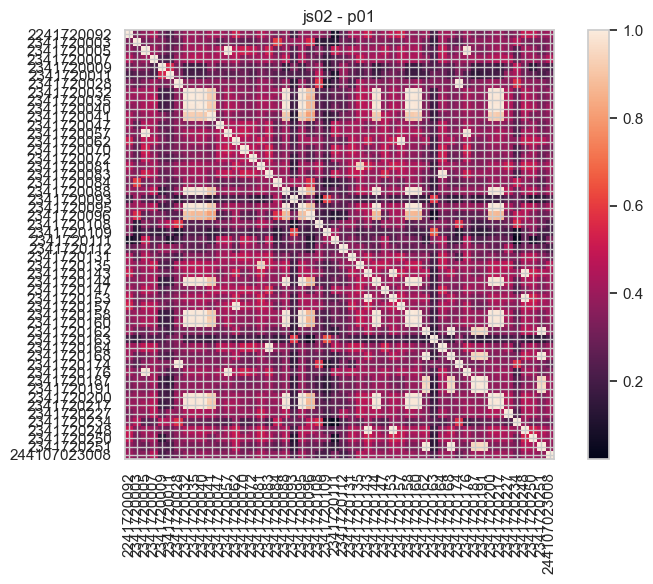

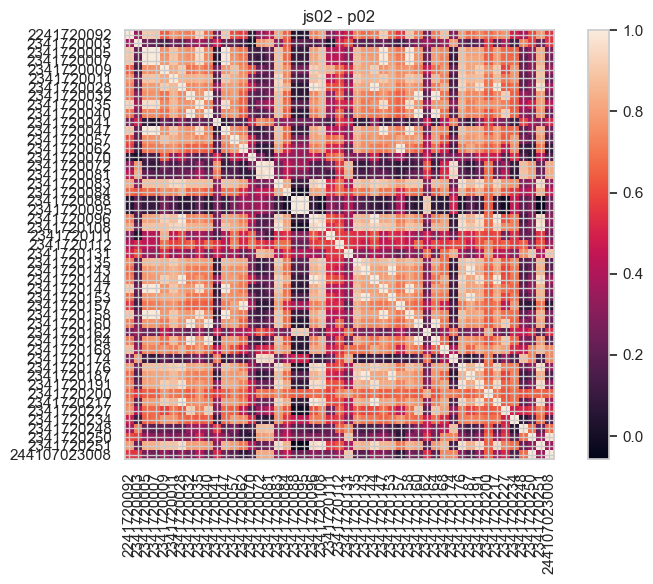

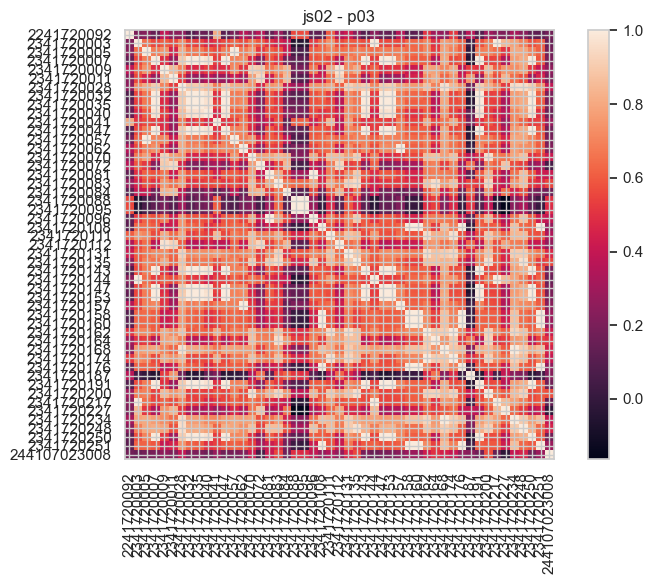

----------------------------------------------------------------------
Total Heatmap Disimpan        : 48
Preview Ditampilkan           : 3


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# ==============================================================================
# FUNCTION HELPER
# ==============================================================================

def build_similarity_matrix(df_meta, embeddings):
    """Membangun matrix similarity dan label nim."""
    sim_matrix = cosine_similarity(embeddings)
    labels = df_meta["nim"].astype(str).tolist()
    return sim_matrix, labels


def plot_heatmap(sim_matrix, labels, title, save_path=None, show=True):
    """Plot heatmap similarity."""
    plt.figure(figsize=(8, 6))

    plt.imshow(sim_matrix)
    plt.colorbar()

    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)

    plt.title(title)
    plt.tight_layout()

    # Simpan gambar
    if save_path:
        plt.savefig(save_path)

    # Kontrol tampil / tidak
    if show:
        plt.show()
    else:
        plt.close()


def generate_heatmaps(input_dir, output_dir, max_preview=2):
    """Generate heatmap per file, tampilkan hanya sebagian."""
    os.makedirs(output_dir, exist_ok=True)

    preview_count = 0
    total_saved = 0

    for root, _, files in os.walk(input_dir):
        for file in files:
            if not file.endswith("_embed.pkl"):
                continue
            if file.startswith("eval_"):
                continue

            path = os.path.join(root, file)

            # Load embedding
            df_meta, embeddings, status, _ = load_embedding_file(path)
            if status != "SUCCESS" or df_meta is None or len(df_meta) < 2:
                continue

            modul = df_meta.loc[0, "modul"]
            filename = df_meta.loc[0, "file"]

            # Build similarity
            sim_matrix, labels = build_similarity_matrix(df_meta, embeddings)

            # Path simpan
            save_path = os.path.join(
                output_dir,
                f"{modul}_{filename.replace('.py','')}_heatmap.png"
            )
            # Tentukan apakah ditampilkan
            show_plot = preview_count < max_preview
            # Plot
            plot_heatmap(
                sim_matrix,
                labels,
                title=f"{modul} - {filename}",
                save_path=save_path,
                show=show_plot
            )

            if show_plot:
                preview_count += 1

            total_saved += 1

    return total_saved, preview_count


# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING']
OUTPUT_DIR = os.path.join(DIRS['LOGS'], "heatmap")
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*70)
print(f"{' HEATMAP VISUALIZATION ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Output Directory':<30}: {OUTPUT_DIR}")

total_saved, preview_count = generate_heatmaps(
    INPUT_DIR,
    OUTPUT_DIR,
    max_preview=3
)

print("-"*70)
print(f"{'Total Heatmap Disimpan':<30}: {total_saved}")
print(f"{'Preview Ditampilkan':<30}: {preview_count}")
print("="*70)